# Temporal Analysis of Flood Events

### Import Modules

In [1]:
# !pip install kaleido

import pandas as pd
import numpy as np

### Load Data

In [2]:
input_data_directory = '../../../../../data/meteorologia/clean'

ocorrencias = pd.read_csv(f'{input_data_directory}/adm_cor_comando/ocorrencias.csv')
pops = pd.read_csv('../../../data/raw/adm_cor_comando/pops.csv', index_col=0)

### Preprocessing `ocorrencias`

In [3]:
# Convert datetime data type fields
ocorrencias['data_inicio'] = pd.to_datetime(ocorrencias['data_inicio'])
ocorrencias['data_fim'] = pd.to_datetime(ocorrencias['data_fim'])

# Map event type
ocorrencias['tipo'] = ocorrencias['id_pop'].map(pops.set_index('id')['titulo'])

### Filter flood events

In [4]:
ocorrencias['tipo'].value_counts().to_frame()

,count
tipo,
Acidente/enguiço sem vítima,39570
Acidente com vítima(s),18310
Operação policial,5038
Bolsão d'água em via,4217
Queda de árvore,3665
Obra em local público,2881
Evento em local público ou particular,2272
Atropelamento,2220
Manifestação em local público,2039


In [5]:
flood_types = [
    "Bolsão d'água em via",
    'Alagamento',
    'Alagamentos e enchentes',
    'Enchente',
    "Lâmina d'água"
]

ocorrencias = ocorrencias[ocorrencias['tipo'].isin(flood_types)]
ocorrencias['tipo'] = ocorrencias['tipo'].replace('Alagamentos e enchentes', 'Alagamento').replace('Enchente', 'Alagamento')

---

## Data Visualization of Flood Events

# Data Visualization of Flood Events in Rio de Janeiro

This Jupyter Notebook implements a comprehensive data visualization plan to analyze flood events in Rio de Janeiro, using the dataset loaded into the `ocorrencias` variable. We will use Plotly for creating interactive and informative visualizations.

## 1. Data Overview & Preprocessing

In this section, we will load the necessary libraries, inspect the dataset, and perform data cleaning and feature engineering steps as outlined in the plan.

In [6]:
# !pip install wordcloud
# !pip install nltk
# !pip install cartopy
# !pip install geopandas
# !pip install rasterio
# !pip install contextily

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# print("First 5 rows of the DataFrame:")
# print(ocorrencias.head())
# print("\nDataFrame Info:")
# print(ocorrencias.info())

### Data Cleaning & Transformation

- Convert “data_inicio” and “data_fim” to datetime objects.
- Compute event duration (in minutes) as a new column.
- Derive additional temporal features (hour, day of week, month, season).
- Handle missing values in `prazo_num` (filling with 0 for now as example).

In [7]:
ocorrencias['duration_seconds'] = (ocorrencias['data_fim'] - ocorrencias['data_inicio']).dt.total_seconds()
ocorrencias['duration_minutes'] = ocorrencias['duration_seconds'] / 60

ocorrencias['hour_start'] = ocorrencias['data_inicio'].dt.hour
ocorrencias['day_of_week'] = ocorrencias['data_inicio'].dt.day_name()
ocorrencias['month'] = ocorrencias['data_inicio'].dt.month_name()
ocorrencias['month_num'] = ocorrencias['data_inicio'].dt.month
ocorrencias['year'] = ocorrencias['data_inicio'].dt.year
ocorrencias['day_of_month'] = ocorrencias['data_inicio'].dt.day
ocorrencias['date'] = pd.to_datetime(ocorrencias['data_inicio'].dt.date)

# Define seasons (for Rio de Janeiro - approximate)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

ocorrencias['season'] = ocorrencias['month_num'].apply(get_season)

# Handle missing values in 'prazo_num' - Fill with 0 for demonstration
ocorrencias['prazo_num'] = ocorrencias['prazo_num'].fillna(0)

print("\nDataFrame after preprocessing:")
display(ocorrencias.head())


DataFrame after preprocessing:


,id_pop,id_evento,bairro,data_inicio,data_fim,prazo,descricao,gravidade,latitude,longitude,...,duration_seconds,duration_minutes,hour_start,day_of_week,month,month_num,year,day_of_month,date,season
622,5.0,66955,Caju,2021-10-15 22:11:46+00:00,2021-10-15 22:16:00+00:00,Curto,"Av. rio de janeiro, 675 - caju",Baixo,-22.891448,-43.214630,...,254.0,4.233333,22,Friday,October,10,2021,15,2021-10-15,Spring
623,5.0,67278,Lagoa,2021-10-24 16:34:17+00:00,2021-10-24 19:52:44+00:00,Curto,"Av. epitácio pessoa, alt. r. garcia d'avila- l...",Baixo,-22.980942,-43.208720,...,11907.0,198.450000,16,Sunday,October,10,2021,24,2021-10-24,Spring
624,5.0,67280,Lagoa,2021-10-24 16:45:02+00:00,2021-10-24 18:19:05+00:00,Curto,"Av. borges de medeiros, alt. r. batista da cos...",Baixo,-22.965323,-43.215881,...,5643.0,94.050000,16,Sunday,October,10,2021,24,2021-10-24,Spring
625,5.0,67279,Lagoa,2021-10-24 16:39:46+00:00,2021-10-24 17:50:16+00:00,Curto,"Viaduto saint hilaire, alt. alça de acesso av....",Baixo,-22.961056,-43.204173,...,4230.0,70.500000,16,Sunday,October,10,2021,24,2021-10-24,Spring
626,5.0,66613,Penha,2021-10-03 17:29:02+00:00,2021-10-03 18:15:23+00:00,Curto,Rua ibiapina - alt. r. monsenhor alves rocha -...,Baixo,-22.841611,-43.276258,...,2781.0,46.350000,17,Sunday,October,10,2021,3,2021-10-03,Spring


### Data Segmentation

- Create subsets for each event type.

In [8]:
bolsao_dagua = ocorrencias[ocorrencias['tipo'] == "Bolsão d'água em via"]
alagamentos = ocorrencias[ocorrencias['tipo'] == "Alagamento"]
lamina_dagua = ocorrencias[ocorrencias['tipo'] == "Lâmina d'água"]

print("\nNumber of 'Bolsão d'água em via' events:", len(bolsao_dagua))
print("Number of 'Alagamento' events:", len(alagamentos))
print("Number of 'Lâmina d'água' events:", len(lamina_dagua))


Number of 'Bolsão d'água em via' events: 4217
Number of 'Alagamento' events: 466
Number of 'Lâmina d'água' events: 185


## 2. Descriptive Statistics & Summary Tables

### Overall Summary Table

- Total number of events, average duration, and overall counts per “gravidade” and “status”.
- Table of descriptive statistics for event durations.

In [9]:
total_events = len(ocorrencias)
avg_duration_minutes = ocorrencias['duration_minutes'].mean()

gravidade_counts = ocorrencias['gravidade'].value_counts().to_frame()
status_counts = ocorrencias['status'].value_counts().to_frame()

duration_stats = ocorrencias['duration_minutes'].describe().to_frame()

print("### Overall Summary")
print(f"Total Number of Events: {total_events}")
print(f"Average Event Duration: {avg_duration_minutes:.2f} minutes")
print("\nCounts by Gravidade:\n")
display(gravidade_counts)
print("\nCounts by Status:\n")
display(status_counts)
print("\nDescriptive Statistics for Event Duration (minutes):\n")
display(duration_stats)

### Overall Summary
Total Number of Events: 4868
Average Event Duration: 243.20 minutes

Counts by Gravidade:



,count
gravidade,
Baixo,4176
Medio,391
Normal,173
Alto,99
Critico,18
Média,7
Sem_classificacao,4



Counts by Status:



,count
status,
Fechado,4864
Aberto,4



Descriptive Statistics for Event Duration (minutes):



,duration_minutes
count,4868.000000
mean,243.201465
std,512.119420
min,0.616667
25%,61.937500
50%,126.966667
75%,238.829167
max,15122.066667


### Event Type Breakdown

- Table showing counts and percentages of each event type.
- Pivot table: rows = “bairro”, columns = “tipo”, values = count of events.

In [10]:
event_type_counts = ocorrencias['tipo'].value_counts().to_frame()
event_type_percentages = (ocorrencias['tipo'].value_counts(normalize=True) * 100).to_frame()

print("\n### Event Type Breakdown")
print("\nEvent Type Counts:\n")
display(event_type_counts)
print("\nEvent Type Percentages:\n")
display(event_type_percentages.map('{:.2f}%'.format))

pivot_table_bairro_tipo = pd.pivot_table(ocorrencias, index='bairro', columns='tipo', aggfunc='size', fill_value=0)
print("\nPivot Table (Bairro vs Tipo):\n")
display(pivot_table_bairro_tipo)


### Event Type Breakdown

Event Type Counts:



,count
tipo,
Bolsão d'água em via,4217
Alagamento,466
Lâmina d'água,185



Event Type Percentages:



,proportion
tipo,
Bolsão d'água em via,86.63%
Alagamento,9.57%
Lâmina d'água,3.80%



Pivot Table (Bairro vs Tipo):



tipo,Alagamento,Bolsão d'água em via,Lâmina d'água
bairro,,,
Abolição,0,3,0
Acari,8,4,0
Alto da boa vista,1,2,0
Anchieta,2,17,0
Andaraí,2,6,0
...,...,...,...
Vila isabel,4,50,1
Vila kosmos,0,1,0
Vila militar,0,4,0


### Temporal Summaries

- Table summarizing counts per month/season and per day-of-week.
- Summary table by “prazo” category.

In [11]:
monthly_counts = ocorrencias['month'].value_counts().sort_index() # Sort by month order
seasonal_counts = ocorrencias['season'].value_counts()
day_of_week_counts = ocorrencias['day_of_week'].value_counts() # Already in day name order

prazo_counts = ocorrencias['prazo'].value_counts()

print("\n### Temporal Summaries")
print("\nMonthly Event Counts:\n")
display(monthly_counts.to_frame())
print("\nSeasonal Event Counts:\n")
display(seasonal_counts.to_frame())
print("\nDay of Week Event Counts:\n")
display(day_of_week_counts.to_frame())
print("\nPrazo Category Counts:\n")
display(prazo_counts.to_frame())


### Temporal Summaries

Monthly Event Counts:



,count
month,
April,508
August,109
December,697
February,969
January,664
July,84
June,114
March,786
May,240



Seasonal Event Counts:



,count
season,
Summer,2330
Autumn,1534
Spring,697
Winter,307



Day of Week Event Counts:



,count
day_of_week,
Monday,874
Thursday,827
Friday,807
Sunday,642
Tuesday,592
Wednesday,569
Saturday,557



Prazo Category Counts:



,count
prazo,
Curto,3025
Desconhecido,1836
Medio,5
Longo,2


## 3. Temporal Visualizations

- Overall Trend: Plot number of events per week/month/season over time.
- Event Frequency Trends: Evaluate time series averages for each frequency (monthly, weekly).

### Process season and month data

In [12]:
## ----- Events per Season -----

# Define a function to map each date to a season
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

# Create season and year-season label
ocorrencias['season'] = ocorrencias['data_inicio'].apply(get_season)
ocorrencias['year'] = ocorrencias['data_inicio'].dt.year

# Adjust year for December (belongs to next year's Summer)
ocorrencias.loc[ocorrencias['data_inicio'].dt.month == 12, 'year'] += 1

# Combine into a single label for plotting
ocorrencias['season_label'] = ocorrencias['year'].astype(str) + '-' + ocorrencias['season']

# Group and count events per season-year
events_per_season = (
    ocorrencias.groupby('season_label')
    .size()
    .reset_index(name='count')
)

# Ensure chronological order
events_per_season['season_order'] = pd.to_datetime(
    events_per_season['season_label'].str.extract(r'(\d{4})')[0] +
    '-' +
    events_per_season['season_label'].str.extract(r'-(\w+)$')[0].map({
        'Summer': '01',
        'Autumn': '04',
        'Winter': '07',
        'Spring': '10'
    })
)
events_per_season = events_per_season.sort_values('season_order')

## ----- Events per Month -----

# Group events by month
events_per_month = (
    ocorrencias
    .groupby(ocorrencias['data_inicio'].dt.to_period('M'))
    .size()
    .reset_index(name='count')
)
events_per_month['data_inicio'] = events_per_month['data_inicio'].dt.to_timestamp()

## ----- Monthly Stats -----

# Extract month and year
ocorrencias['year'] = ocorrencias['data_inicio'].dt.year
ocorrencias['month'] = ocorrencias['data_inicio'].dt.month

# Group by year and month
monthly_counts = (
    ocorrencias
    .groupby(['year', 'month'])
    .size()
    .reset_index(name='count')
)

# Compute mean and std per month (across years)
monthly_stats = (
    monthly_counts
    .groupby('month')['count']
    .agg(['mean', 'std'])
    .reset_index()
)

# Add bounds for variance band
monthly_stats['upper'] = monthly_stats['mean'] + monthly_stats['std']
monthly_stats['lower'] = monthly_stats['mean'] - monthly_stats['std']

# Month names for x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_stats['month_name'] = monthly_stats['month'].apply(lambda x: month_names[x-1])

## ----- Events per Week -----

# Group events by week
events_per_week = (
    ocorrencias
    .groupby(ocorrencias['data_inicio'].dt.to_period('W'))
    .size()
    .reset_index(name='count')
)
events_per_week['week_start'] = events_per_week['data_inicio'].dt.to_timestamp()

## ----- Weekly Stats -----

# Extract ISO week and year
ocorrencias['year'] = ocorrencias['data_inicio'].dt.year
ocorrencias['week_of_year'] = ocorrencias['data_inicio'].dt.isocalendar().week

# Group by week and year, then aggregate event counts
weekly_counts = (
    ocorrencias
    .groupby(['year', 'week_of_year'])
    .size()
    .reset_index(name='count')
)

# Compute stats: mean and std per week across years
weekly_stats = (
    weekly_counts
    .groupby('week_of_year')['count']
    .agg(['mean', 'std'])
    .reset_index()
)

# Compute upper/lower bounds for variance band
weekly_stats['upper'] = weekly_stats['mean'] + weekly_stats['std']
weekly_stats['lower'] = weekly_stats['mean'] - weekly_stats['std']

## ----- Hourly Stats -----

# Extract hour and date
ocorrencias['hour'] = ocorrencias['data_inicio'].dt.hour
ocorrencias['date'] = ocorrencias['data_inicio'].dt.date  # to separate by day

# Count events per hour per day
hourly_counts = (
    ocorrencias
    .groupby(['date', 'hour'])
    .size()
    .reset_index(name='count')
)

# Compute mean and std per hour across all days
hourly_stats = (
    hourly_counts
    .groupby('hour')['count']
    .agg(['mean', 'std'])
    .reset_index()
)

# Add bounds for shaded variance band
hourly_stats['upper'] = hourly_stats['mean'] + hourly_stats['std']
hourly_stats['lower'] = hourly_stats['mean'] - hourly_stats['std']

/tmp/ipykernel_38094/1872257491.py:50: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(ocorrencias['data_inicio'].dt.to_period('M'))
/tmp/ipykernel_38094/1872257491.py:92: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(ocorrencias['data_inicio'].dt.to_period('W'))


### Monthly Time Series Line Chart (by Season)

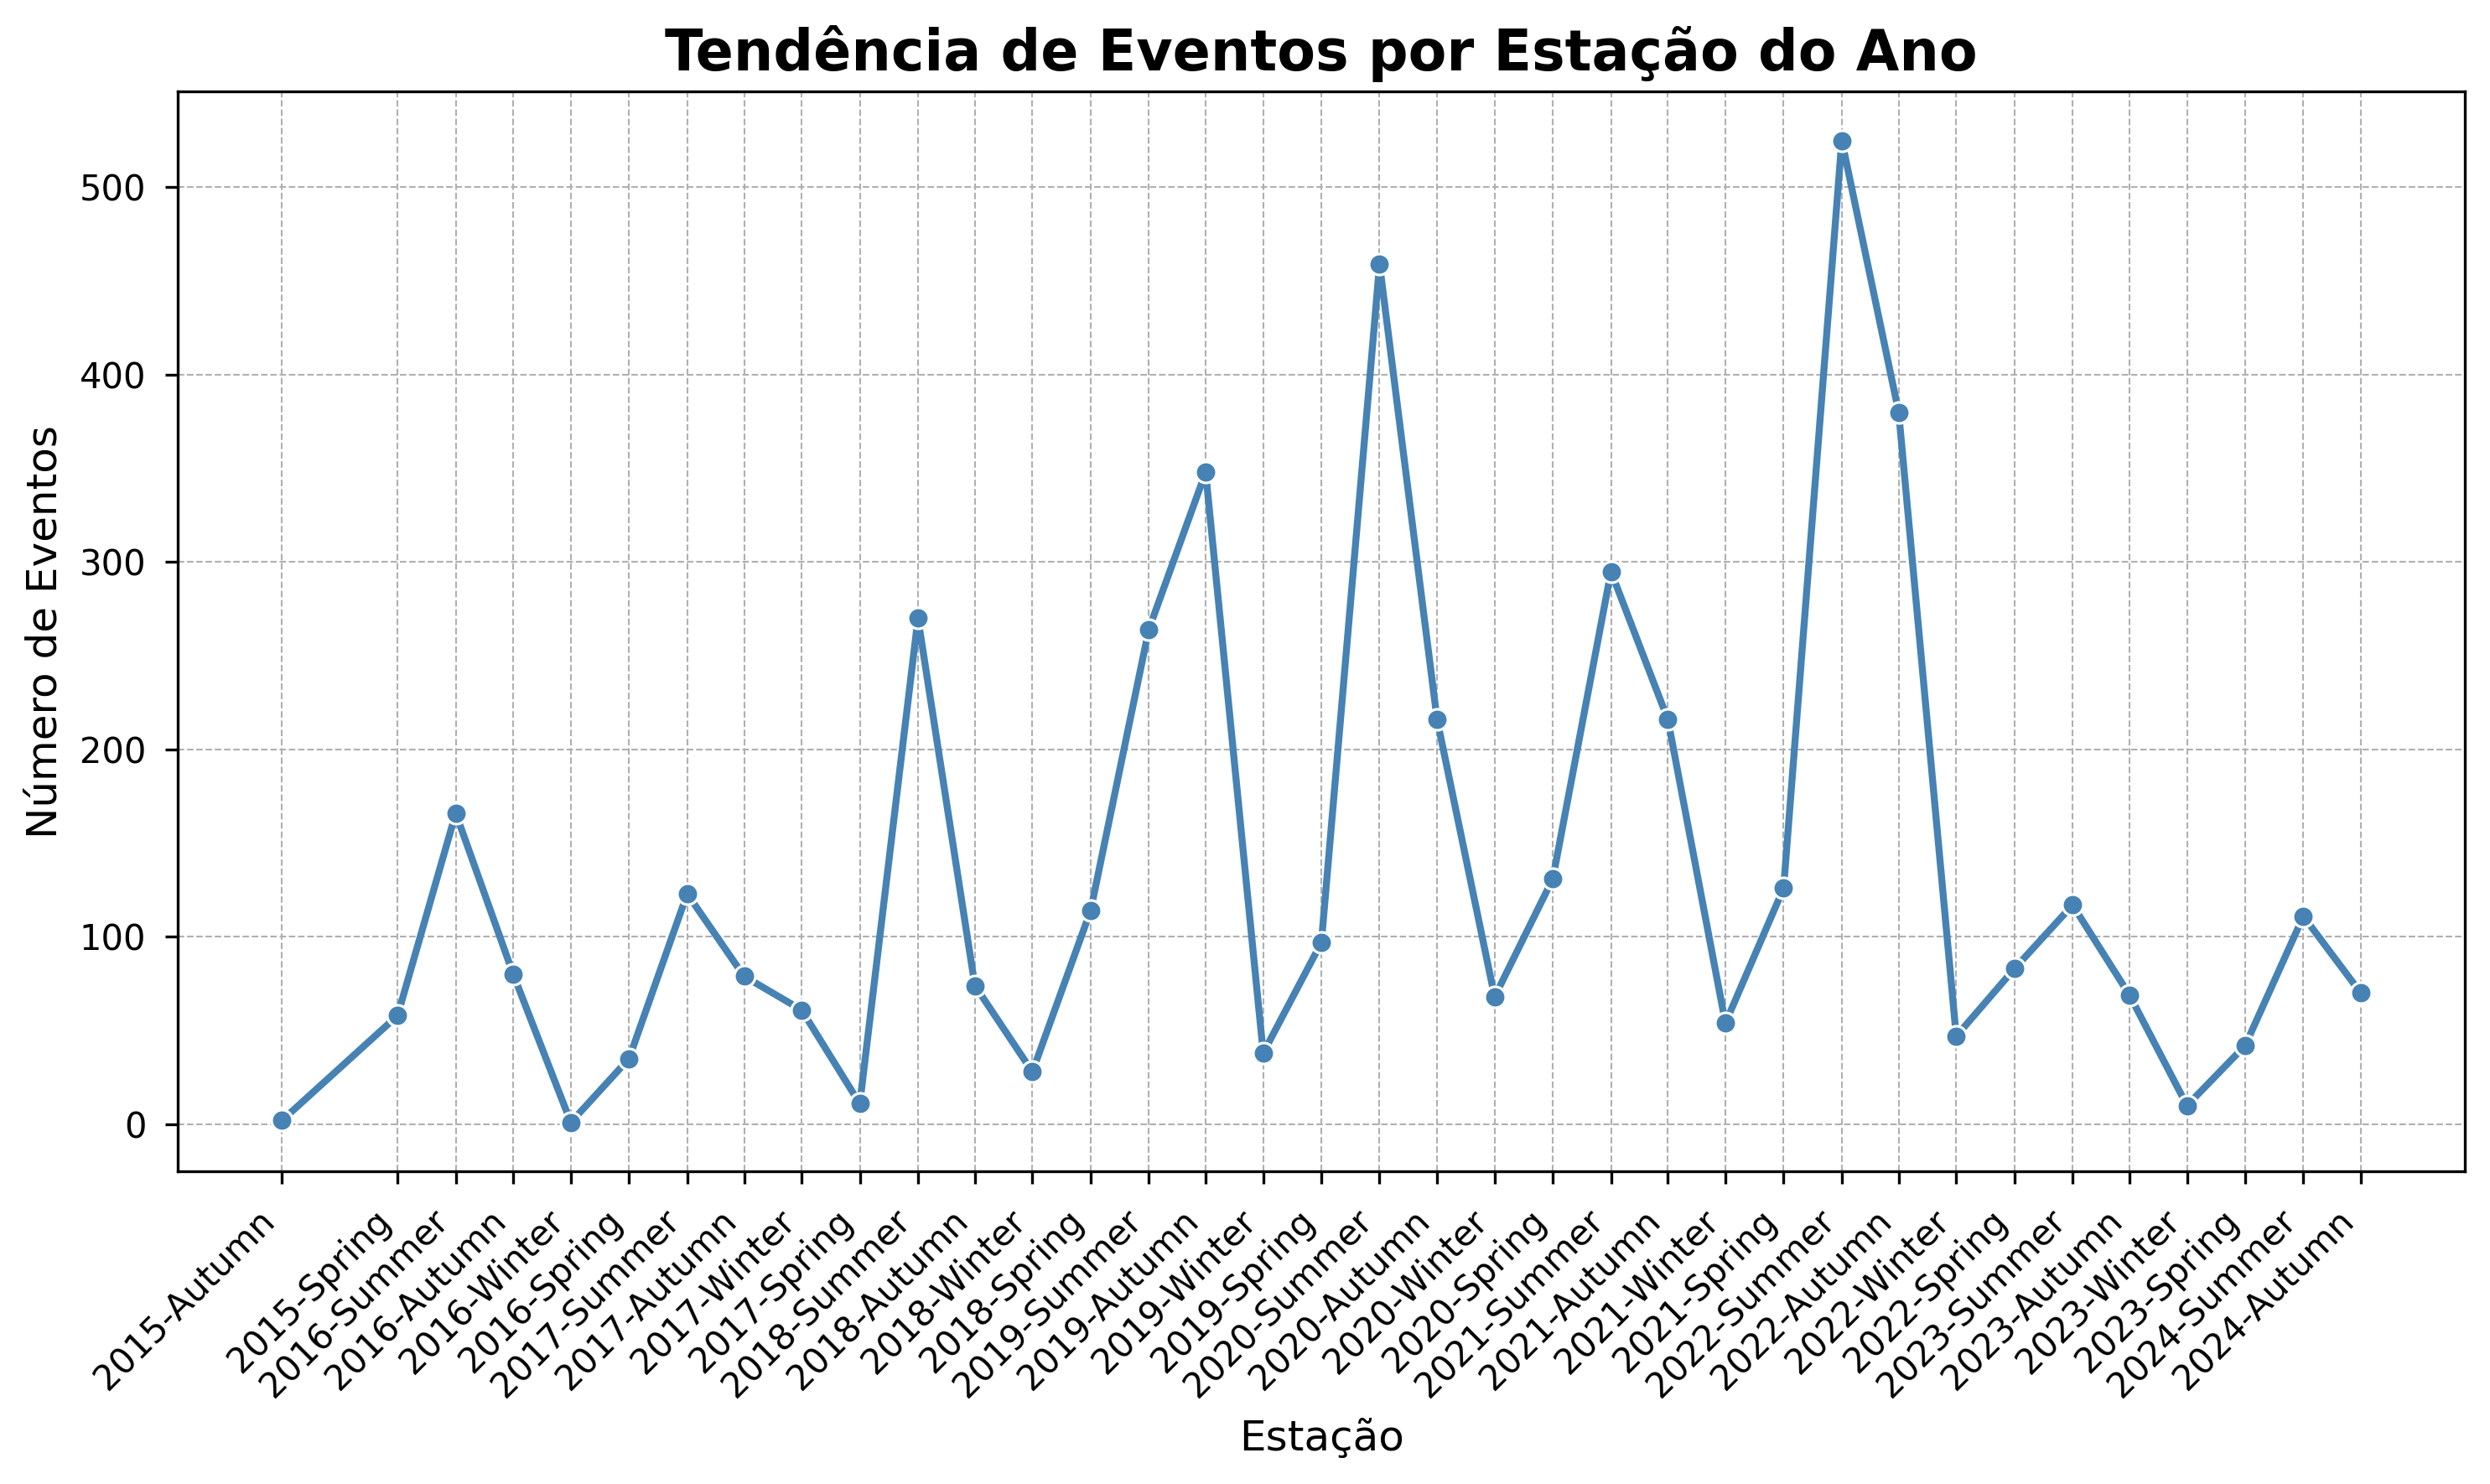

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## ----- Events per Season -----

# Define a function to map each date to a season
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

# Create season and year-season label
ocorrencias['season'] = ocorrencias['data_inicio'].apply(get_season)
ocorrencias['year'] = ocorrencias['data_inicio'].dt.year

# Adjust year for December (belongs to next year's Summer)
ocorrencias.loc[ocorrencias['data_inicio'].dt.month == 12, 'year'] += 1

# Combine into a single label for plotting
ocorrencias['season_label'] = ocorrencias['year'].astype(str) + '-' + ocorrencias['season']

# Group and count events per season-year
events_per_season = (
    ocorrencias.groupby('season_label')
    .size()
    .reset_index(name='count')
)

# Ensure chronological order
events_per_season['season_order'] = pd.to_datetime(
    events_per_season['season_label'].str.extract(r'(\d{4})')[0] +
    '-' +
    events_per_season['season_label'].str.extract(r'-(\w+)$')[0].map({
        'Summer': '01',
        'Autumn': '04',
        'Winter': '07',
        'Spring': '10'
    })
)
events_per_season = events_per_season.sort_values('season_order')

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico de Linha: Tendência de Eventos por Estação ---
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=events_per_season,
    x='season_order',
    y='count',
    marker='o',
    markersize=6,
    linewidth=2,
    color='steelblue',
    ax=ax
)

# Estilização
ax.set_title('Tendência de Eventos por Estação do Ano', fontsize=16, weight='bold')
ax.set_xlabel('Estação', fontsize=12)
ax.set_ylabel('Número de Eventos', fontsize=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

# Formatação do eixo X para mostrar os rótulos de estação customizados
ax.set_xticks(events_per_season['season_order'])
ax.set_xticklabels(events_per_season['season_label'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Monthly Time Series Line Chart (by Month)

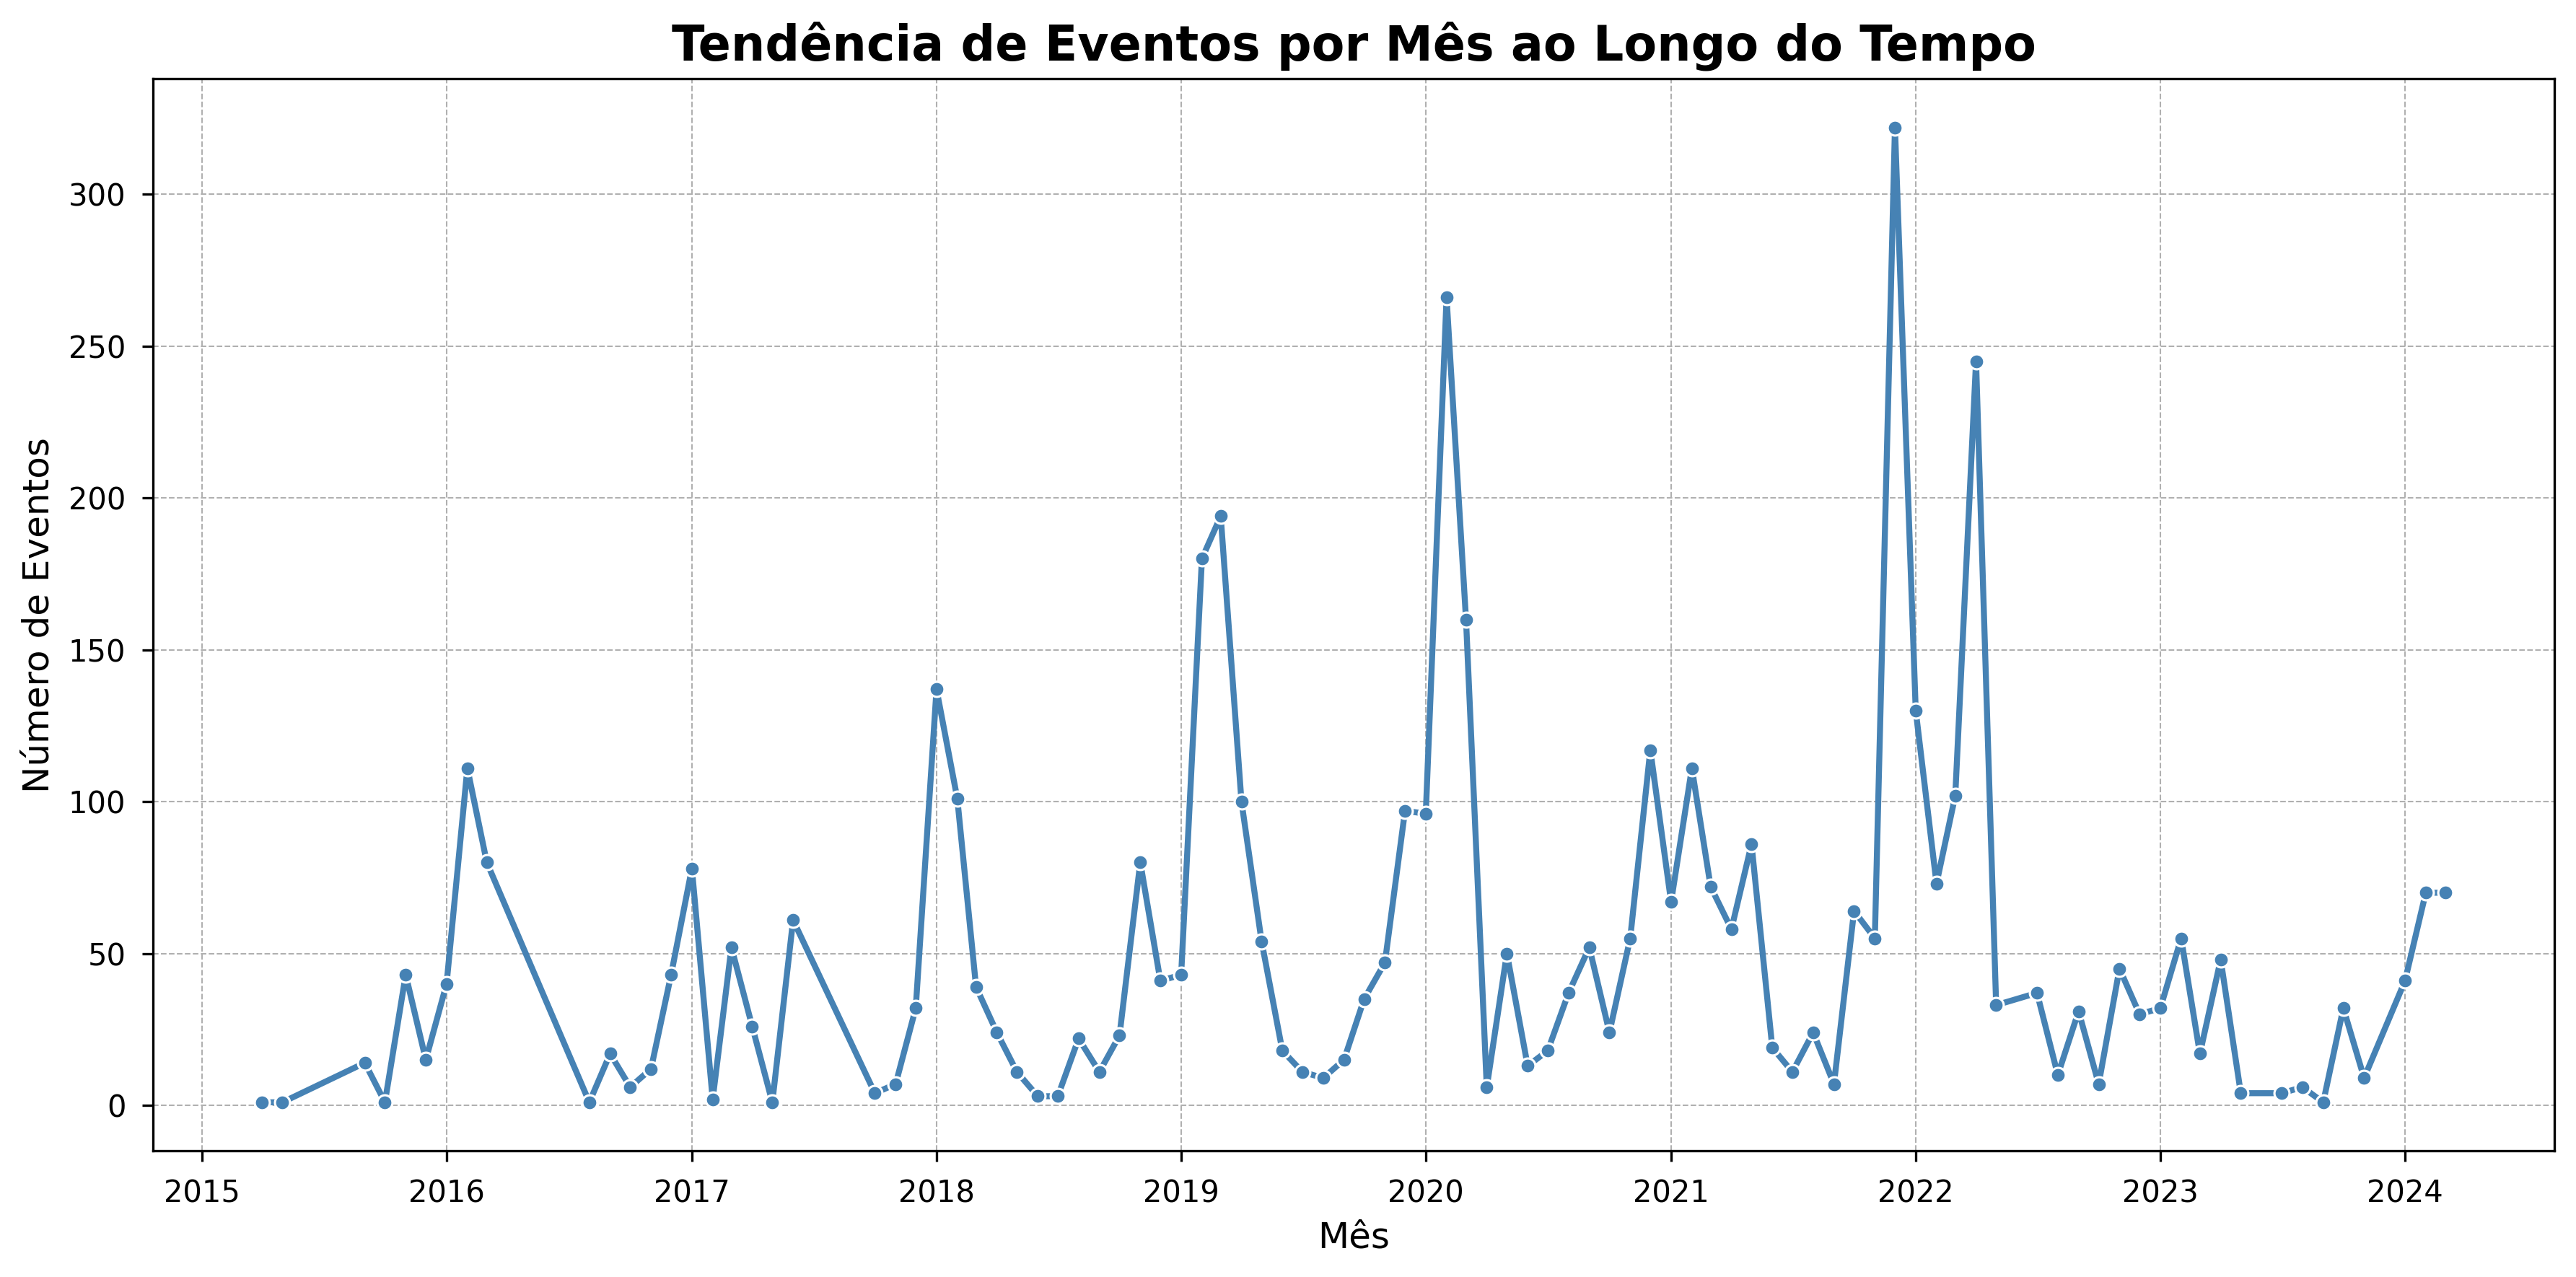

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico de Linha: Tendência de Eventos por Mês ---
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=events_per_month,
    x='data_inicio',
    y='count',
    marker='o',
    markersize=5,
    linewidth=2,
    color='steelblue',
    ax=ax
)

# Estilização
ax.set_title('Tendência de Eventos por Mês ao Longo do Tempo', fontsize=16, weight='bold')
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Número de Eventos', fontsize=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

# Formatação do eixo X para exibir 'Mês Ano'
# ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1, interval=3)) # Ticks a cada 3 meses
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.show()

### Monthly Time Series Average

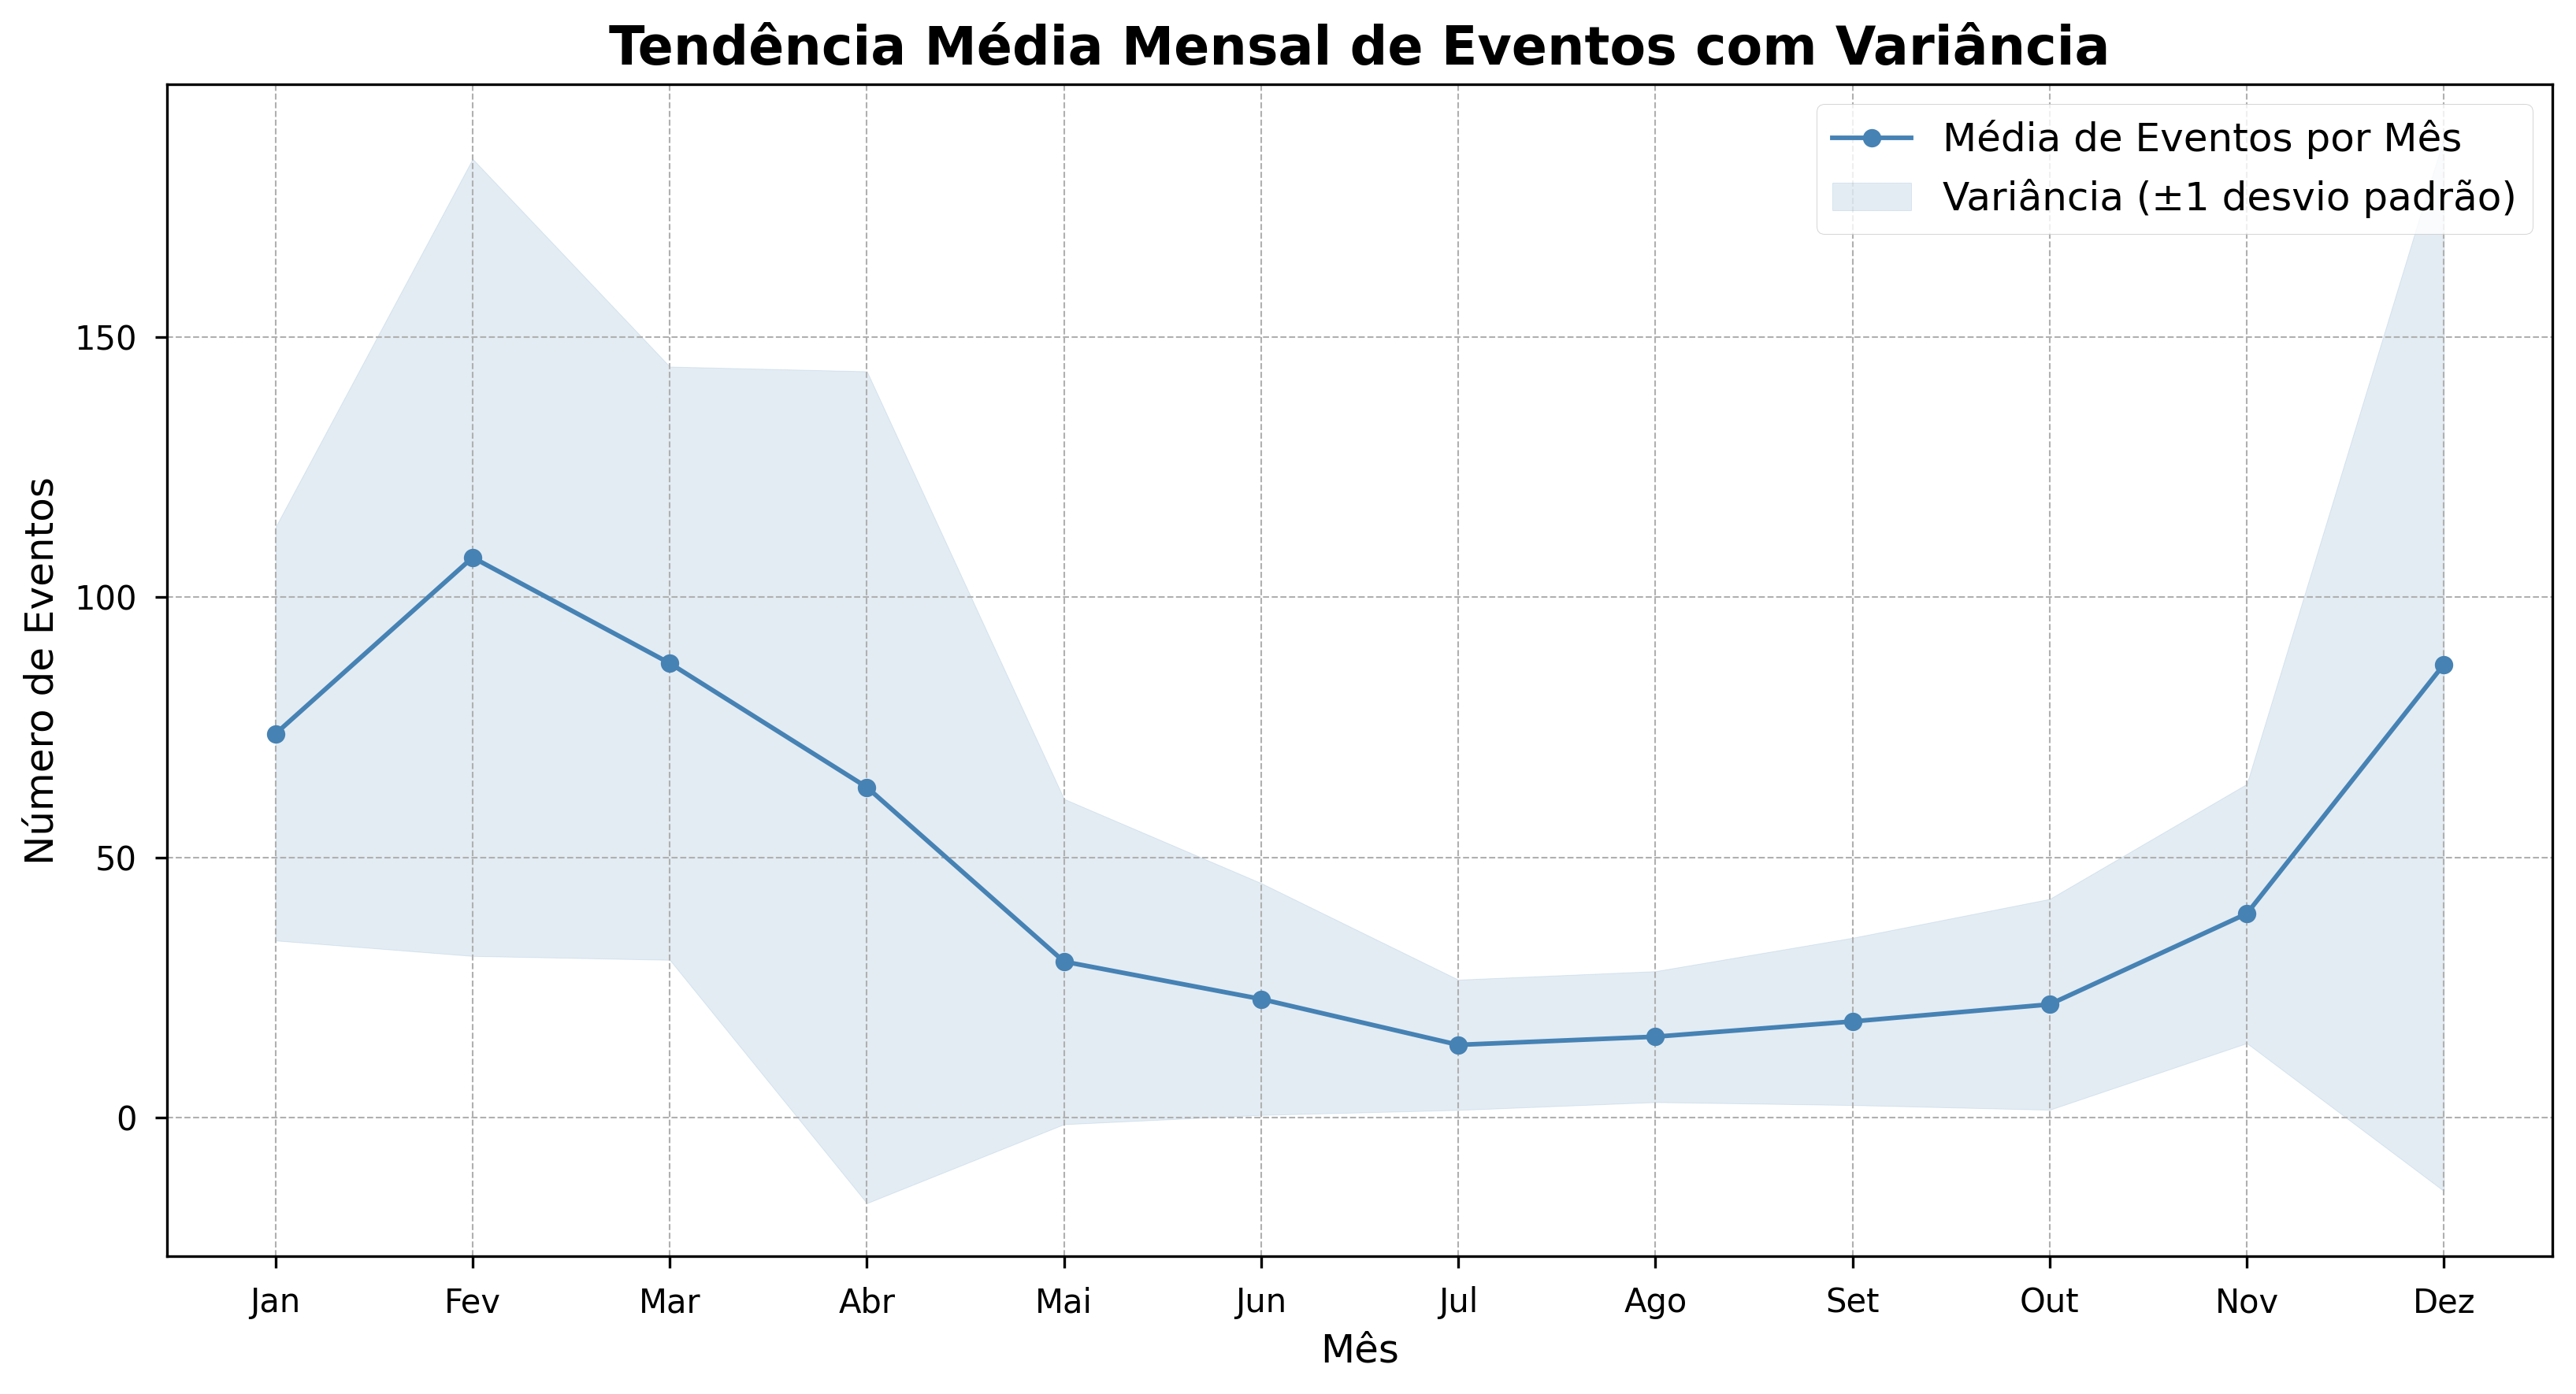

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# Mapear meses para português
meses_pt = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
monthly_stats['month_name_pt'] = monthly_stats['month'].apply(lambda x: meses_pt[x-1])

# --- Gráfico de Média Mensal com Variância ---
fig, ax = plt.subplots(figsize=(11, 6))

# Linha da média
ax.plot(monthly_stats['month_name_pt'], monthly_stats['mean'],
        marker='o', linestyle='-', color='steelblue', label='Média de Eventos por Mês')

# Banda de variância (±1 desvio padrão)
ax.fill_between(monthly_stats['month_name_pt'], monthly_stats['lower'], monthly_stats['upper'],
                color='steelblue', alpha=0.15, label='Variância (±1 desvio padrão)')

# Estilização
ax.set_title('Tendência Média Mensal de Eventos com Variância', fontsize=16, weight='bold')
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Número de Eventos', fontsize=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.legend(loc='upper right', fontsize=12)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

# Garante que todos os meses sejam mostrados
plt.xticks(monthly_stats['month_name_pt'])

plt.tight_layout()
plt.show()

### Weekly Time Series Line Charts

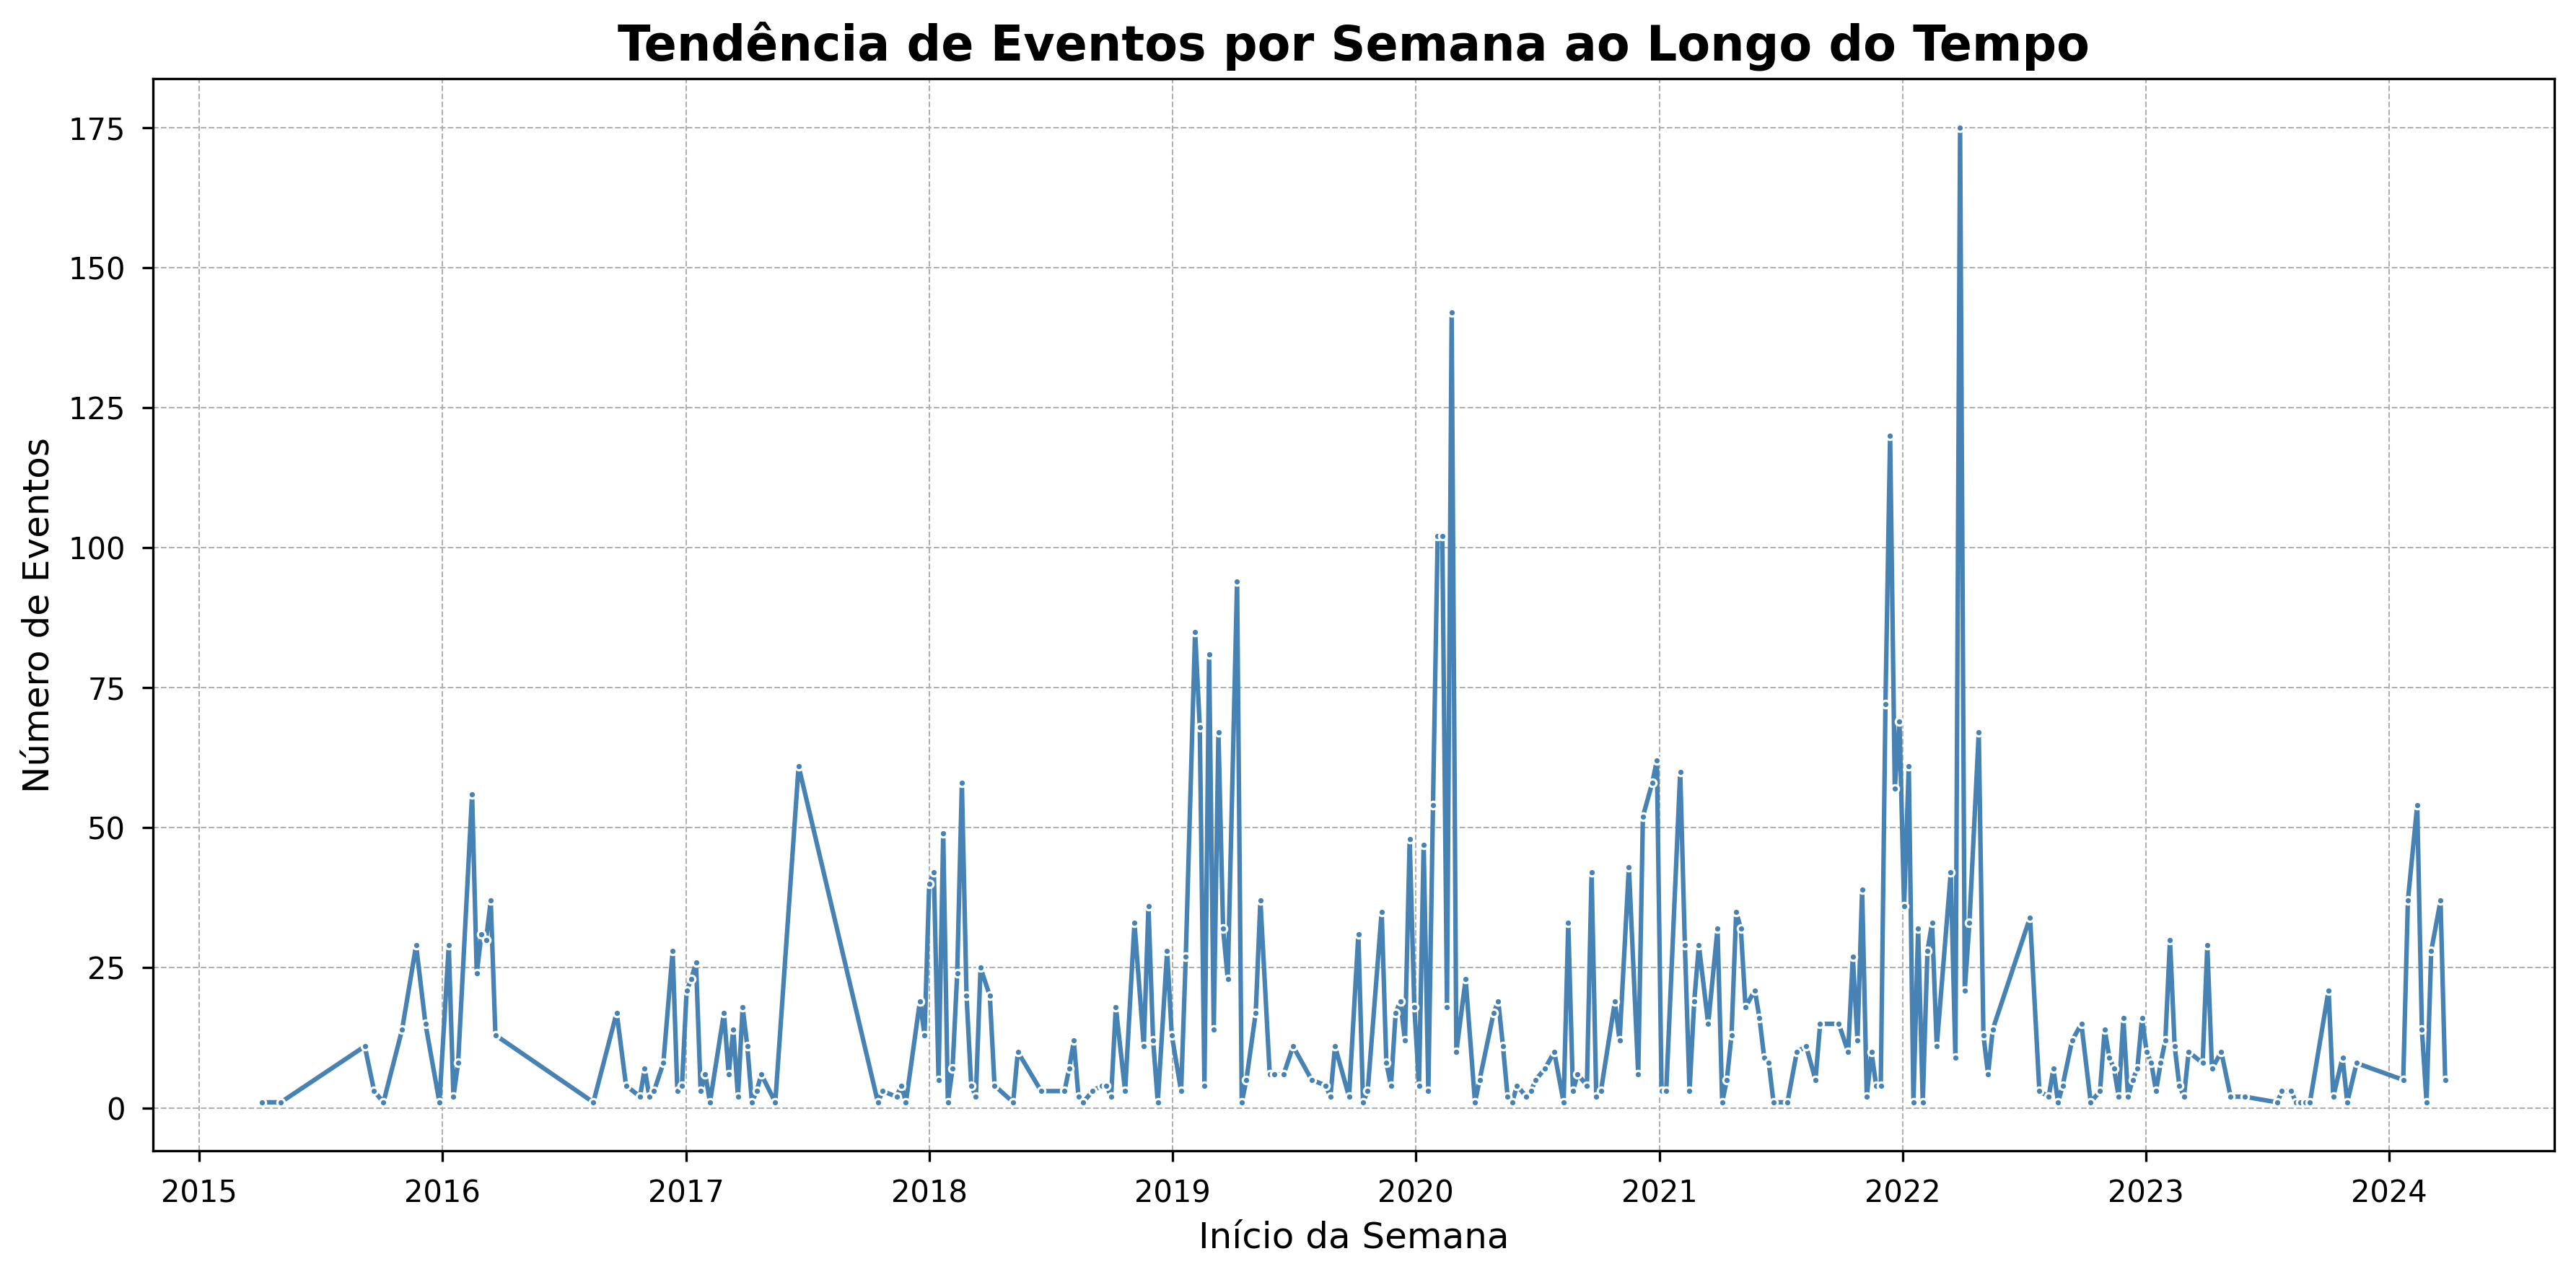

In [16]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico de Linha: Tendência de Eventos por Semana ---
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=events_per_week,
    x='week_start',
    y='count',
    marker='.', # Pontos menores para dados mais densos
    markersize=5,
    linewidth=1.5,
    color='steelblue',
    ax=ax
)

# Estilização
ax.set_title('Tendência de Eventos por Semana ao Longo do Tempo', fontsize=16, weight='bold')
ax.set_xlabel('Início da Semana', fontsize=12)
ax.set_ylabel('Número de Eventos', fontsize=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

# Formatação do eixo X
# ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1, interval=2)) # Ticks a cada 2 meses
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b\n%Y'))

plt.tight_layout()
plt.show()

### Weekly Time Series Average

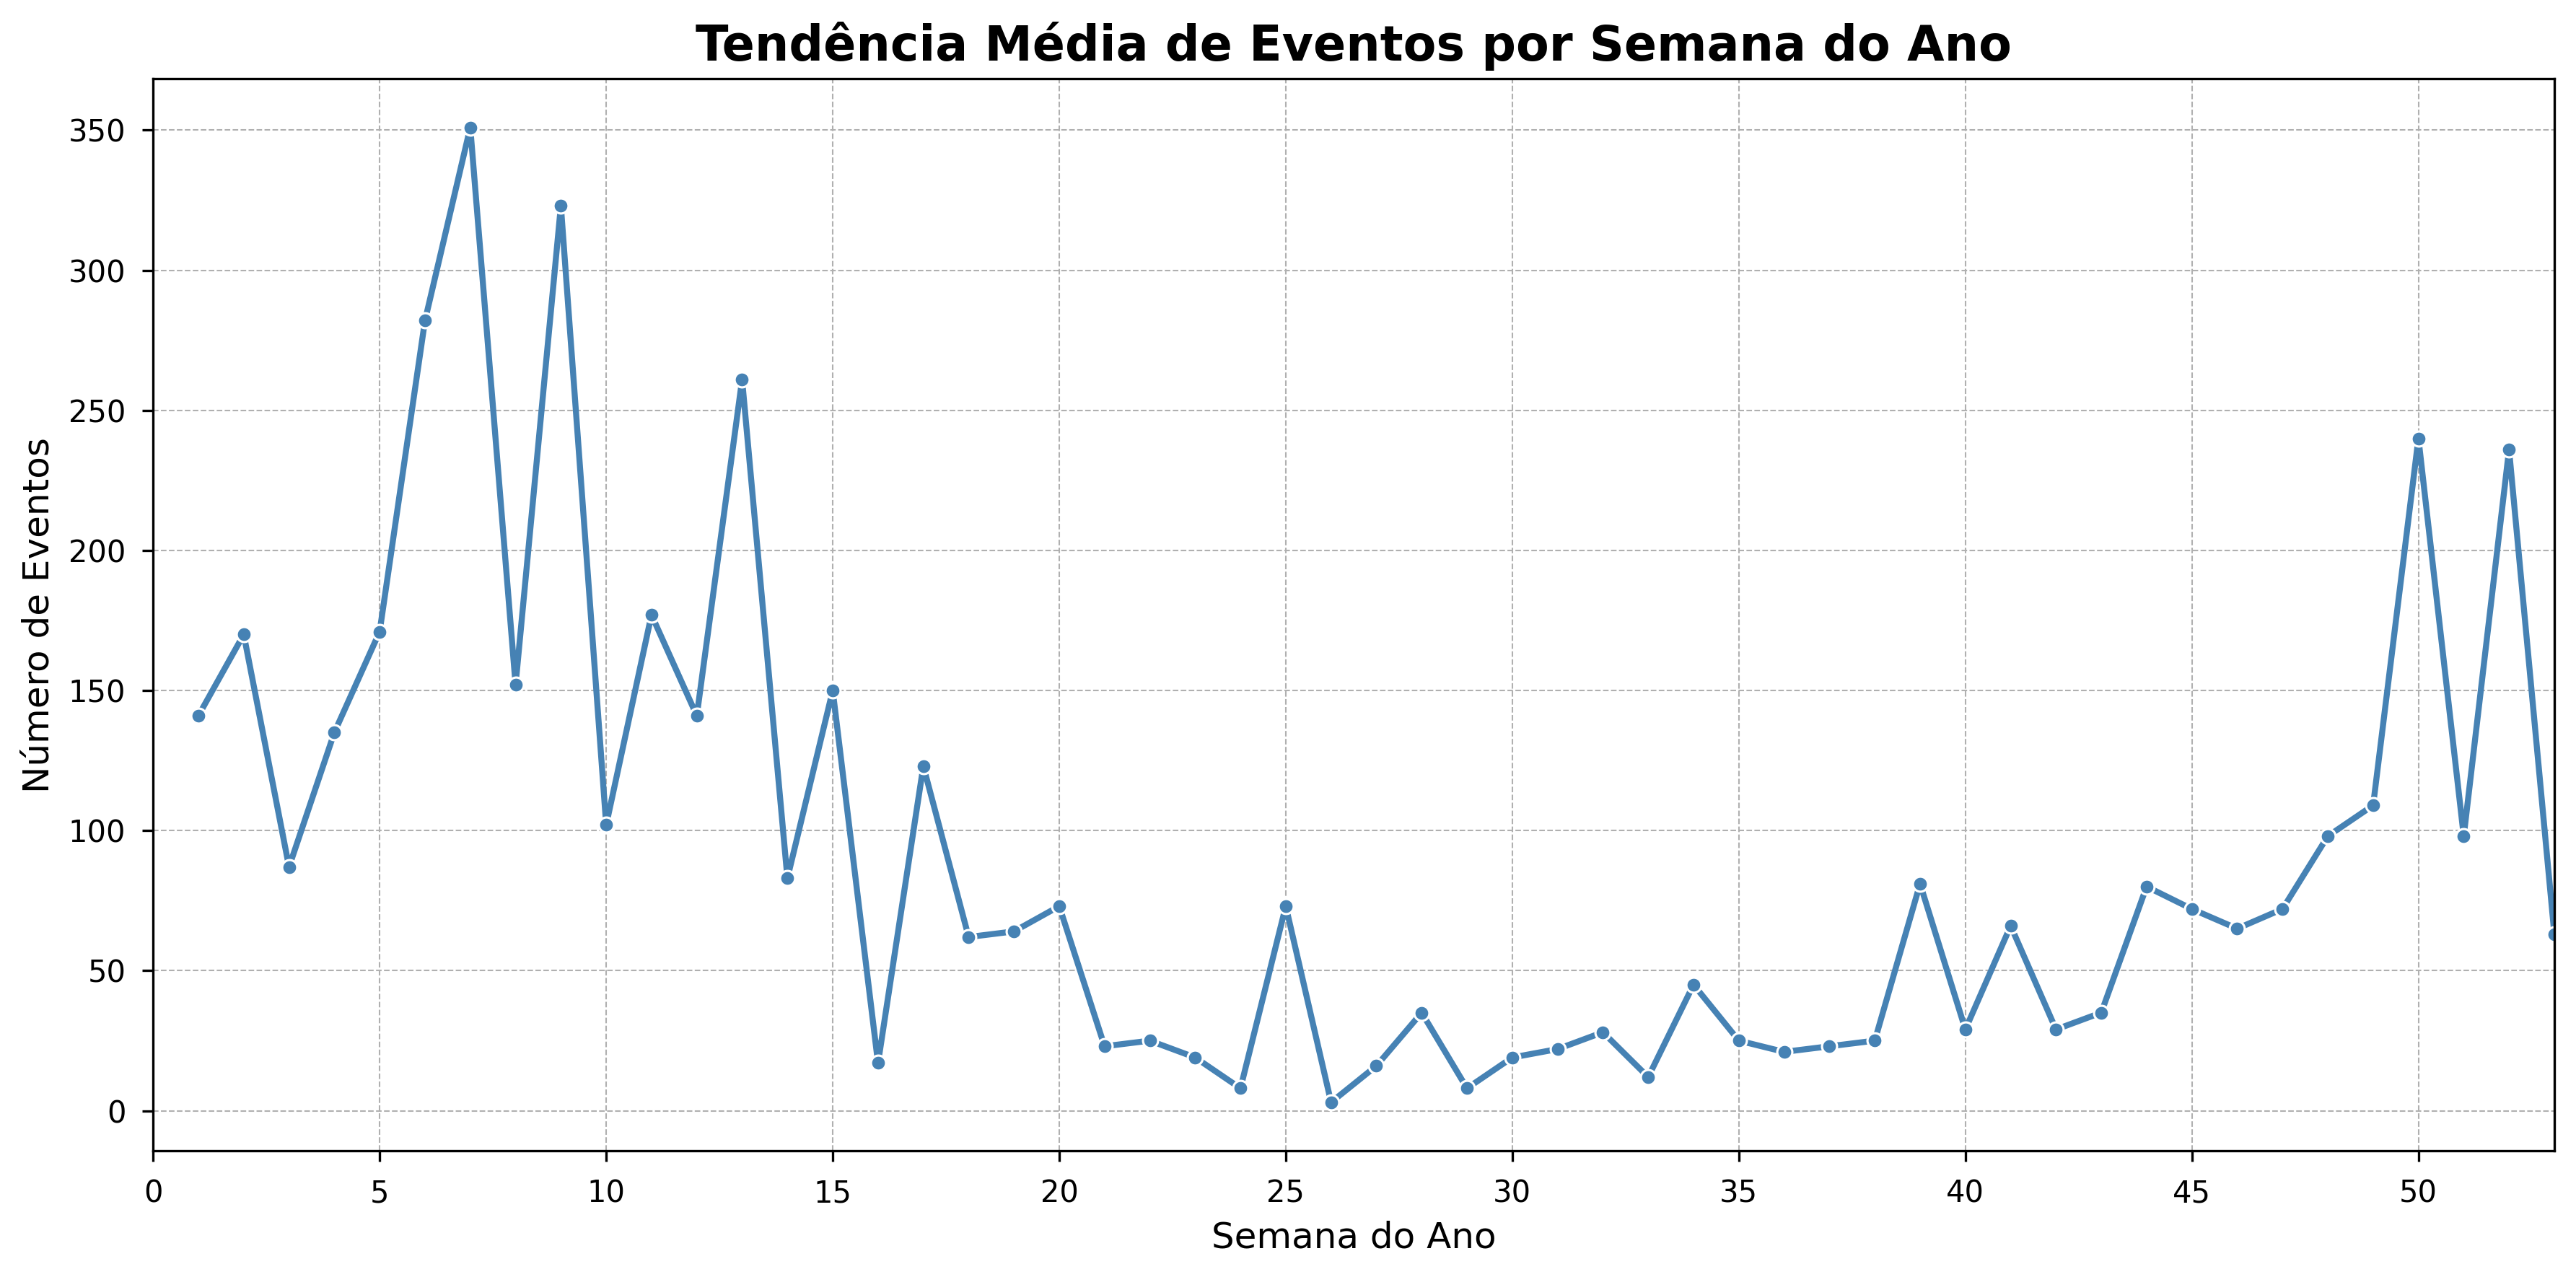

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# Re-criação do dataframe 'events_per_week' (do código original)
ocorrencias['week_of_year'] = ocorrencias['data_inicio'].dt.isocalendar().week
events_per_week_avg = (
    ocorrencias.groupby('week_of_year')
    .size()
    .reset_index(name='count')
    .sort_values('week_of_year')
)

# --- Gráfico de Linha: Média de Eventos por Semana do Ano ---
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=events_per_week_avg,
    x='week_of_year',
    y='count',
    marker='o',
    markersize=5,
    linewidth=2,
    color='steelblue',
    ax=ax
)

# Estilização
ax.set_title('Tendência Média de Eventos por Semana do Ano', fontsize=16, weight='bold')
ax.set_xlabel('Semana do Ano', fontsize=12)
ax.set_ylabel('Número de Eventos', fontsize=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.set_xlim(0, 53) # Limites do eixo X de 1 a 52/53
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=13)) # Ticks em intervalos regulares
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

plt.tight_layout()
plt.show()

### Weekly Time Series Average with Variance

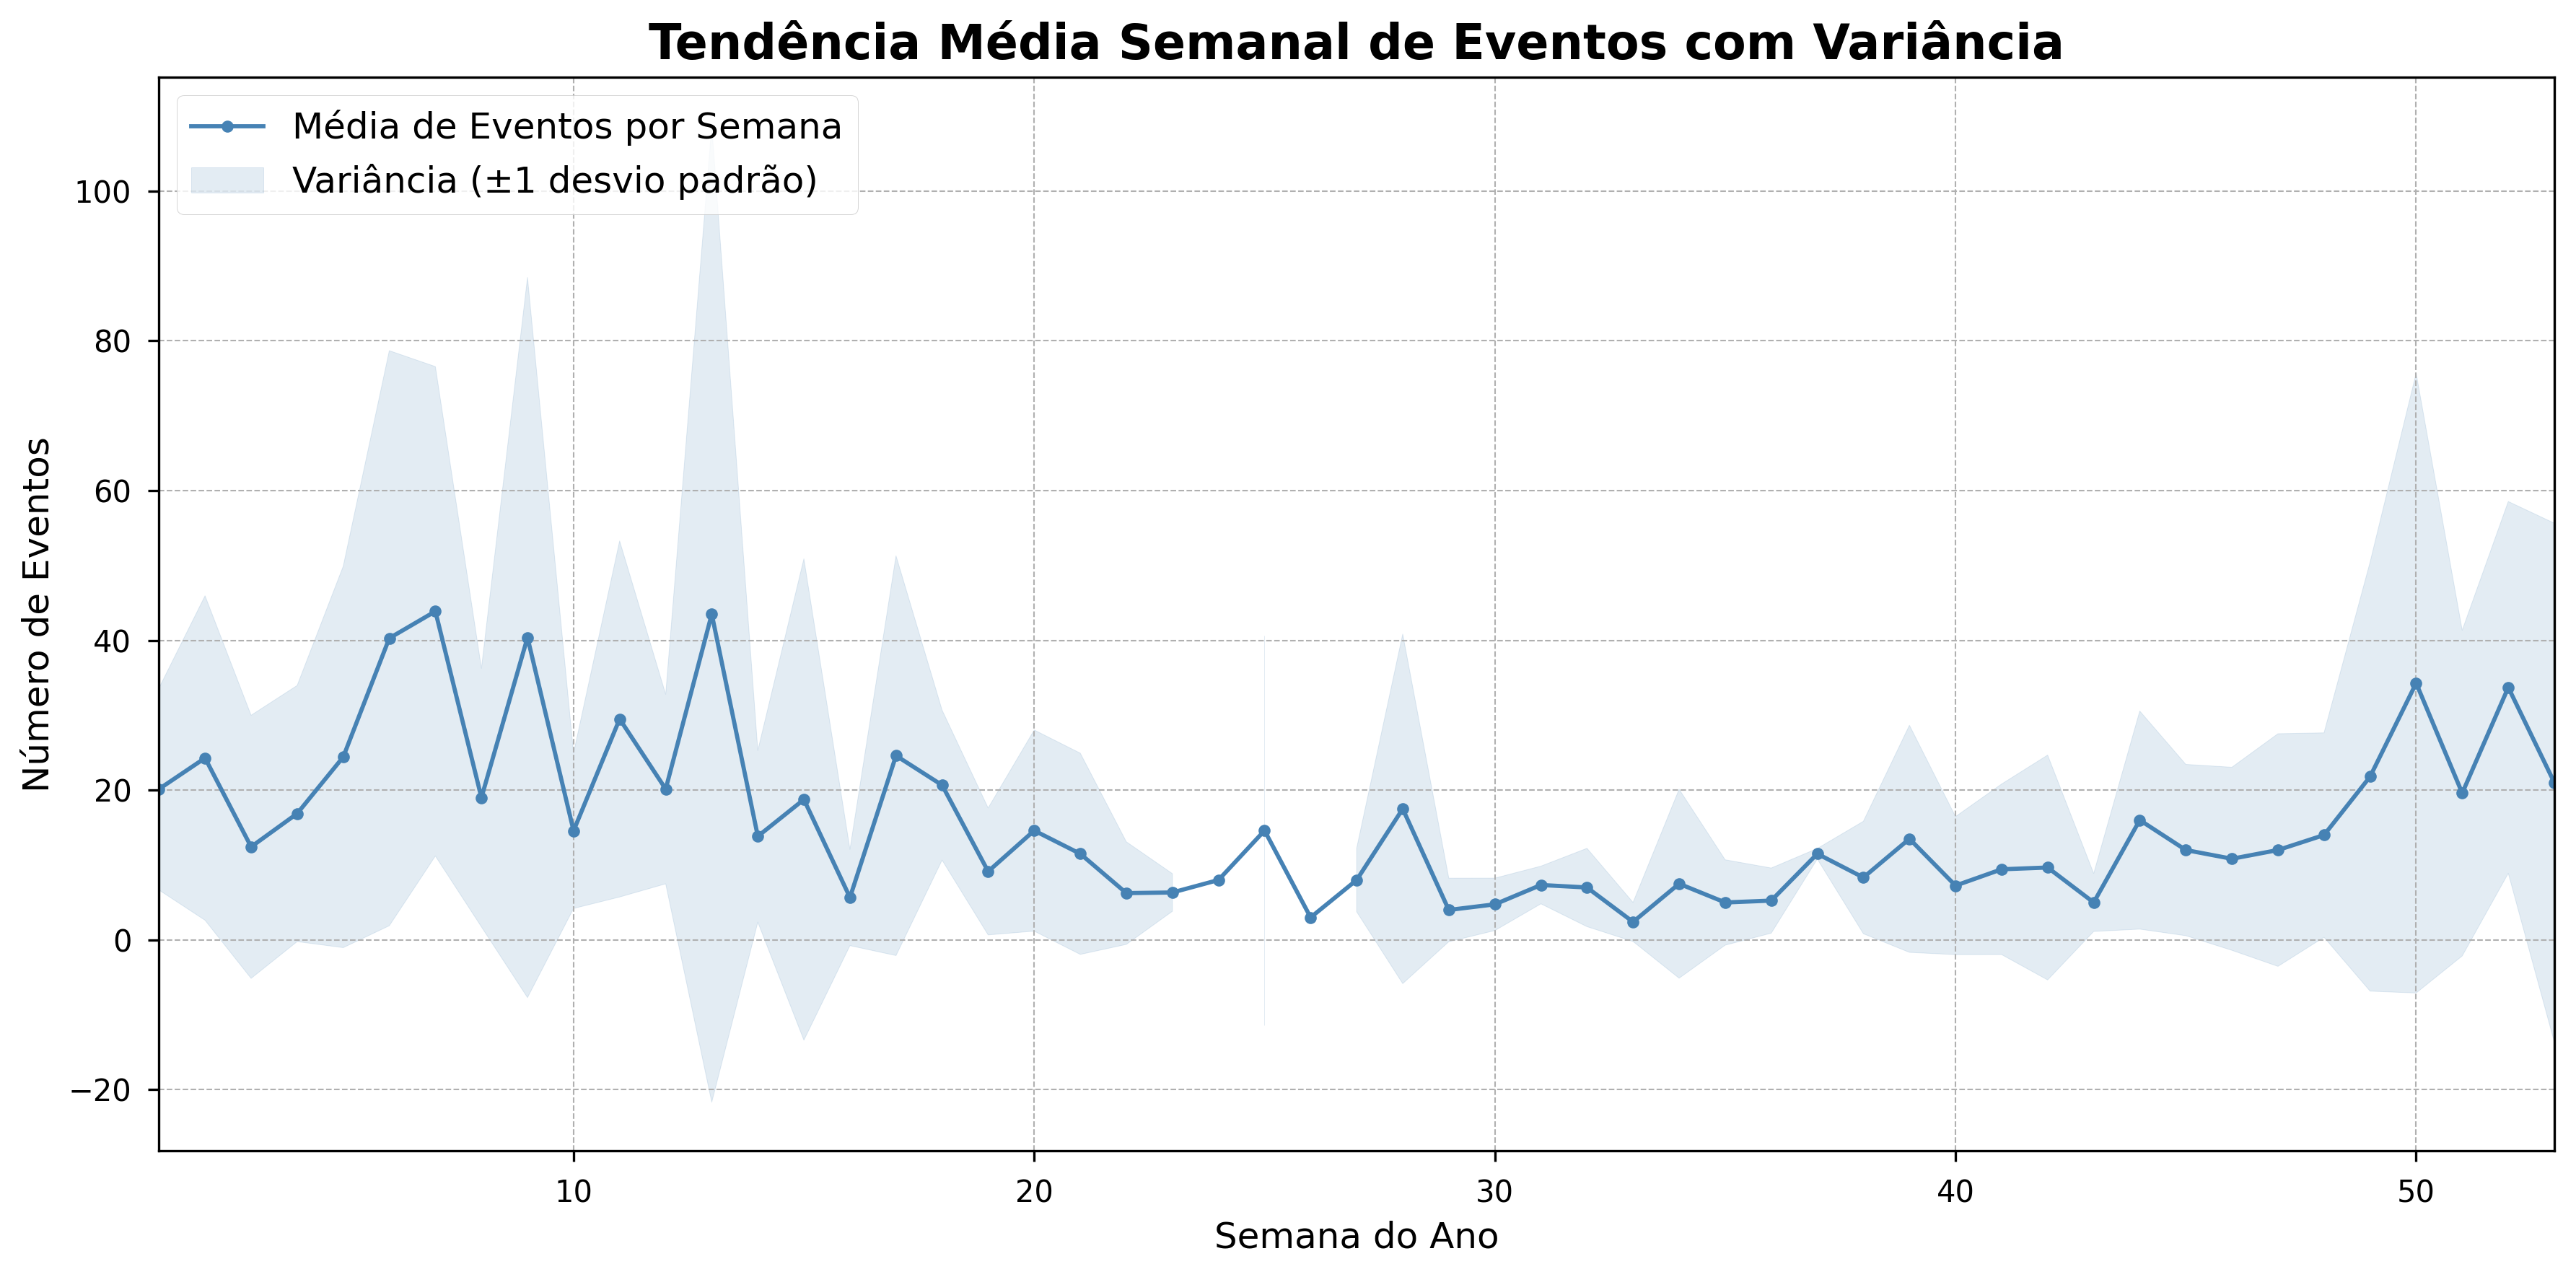

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico de Média Semanal com Variância ---
fig, ax = plt.subplots(figsize=(12, 6))

# Linha da média
ax.plot(weekly_stats['week_of_year'], weekly_stats['mean'],
        marker='o', linestyle='-', markersize=4, color='steelblue', label='Média de Eventos por Semana')

# Banda de variância (±1 desvio padrão)
ax.fill_between(weekly_stats['week_of_year'], weekly_stats['lower'], weekly_stats['upper'],
                color='steelblue', alpha=0.15, label='Variância (±1 desvio padrão)')

# Estilização
ax.set_title('Tendência Média Semanal de Eventos com Variância', fontsize=16, weight='bold')
ax.set_xlabel('Semana do Ano', fontsize=12)
ax.set_ylabel('Número de Eventos', fontsize=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.legend(loc='upper left', fontsize=12)
ax.set_xlim(1, 53)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

plt.tight_layout()
plt.show()

### Hourly Time Series Average with Variance

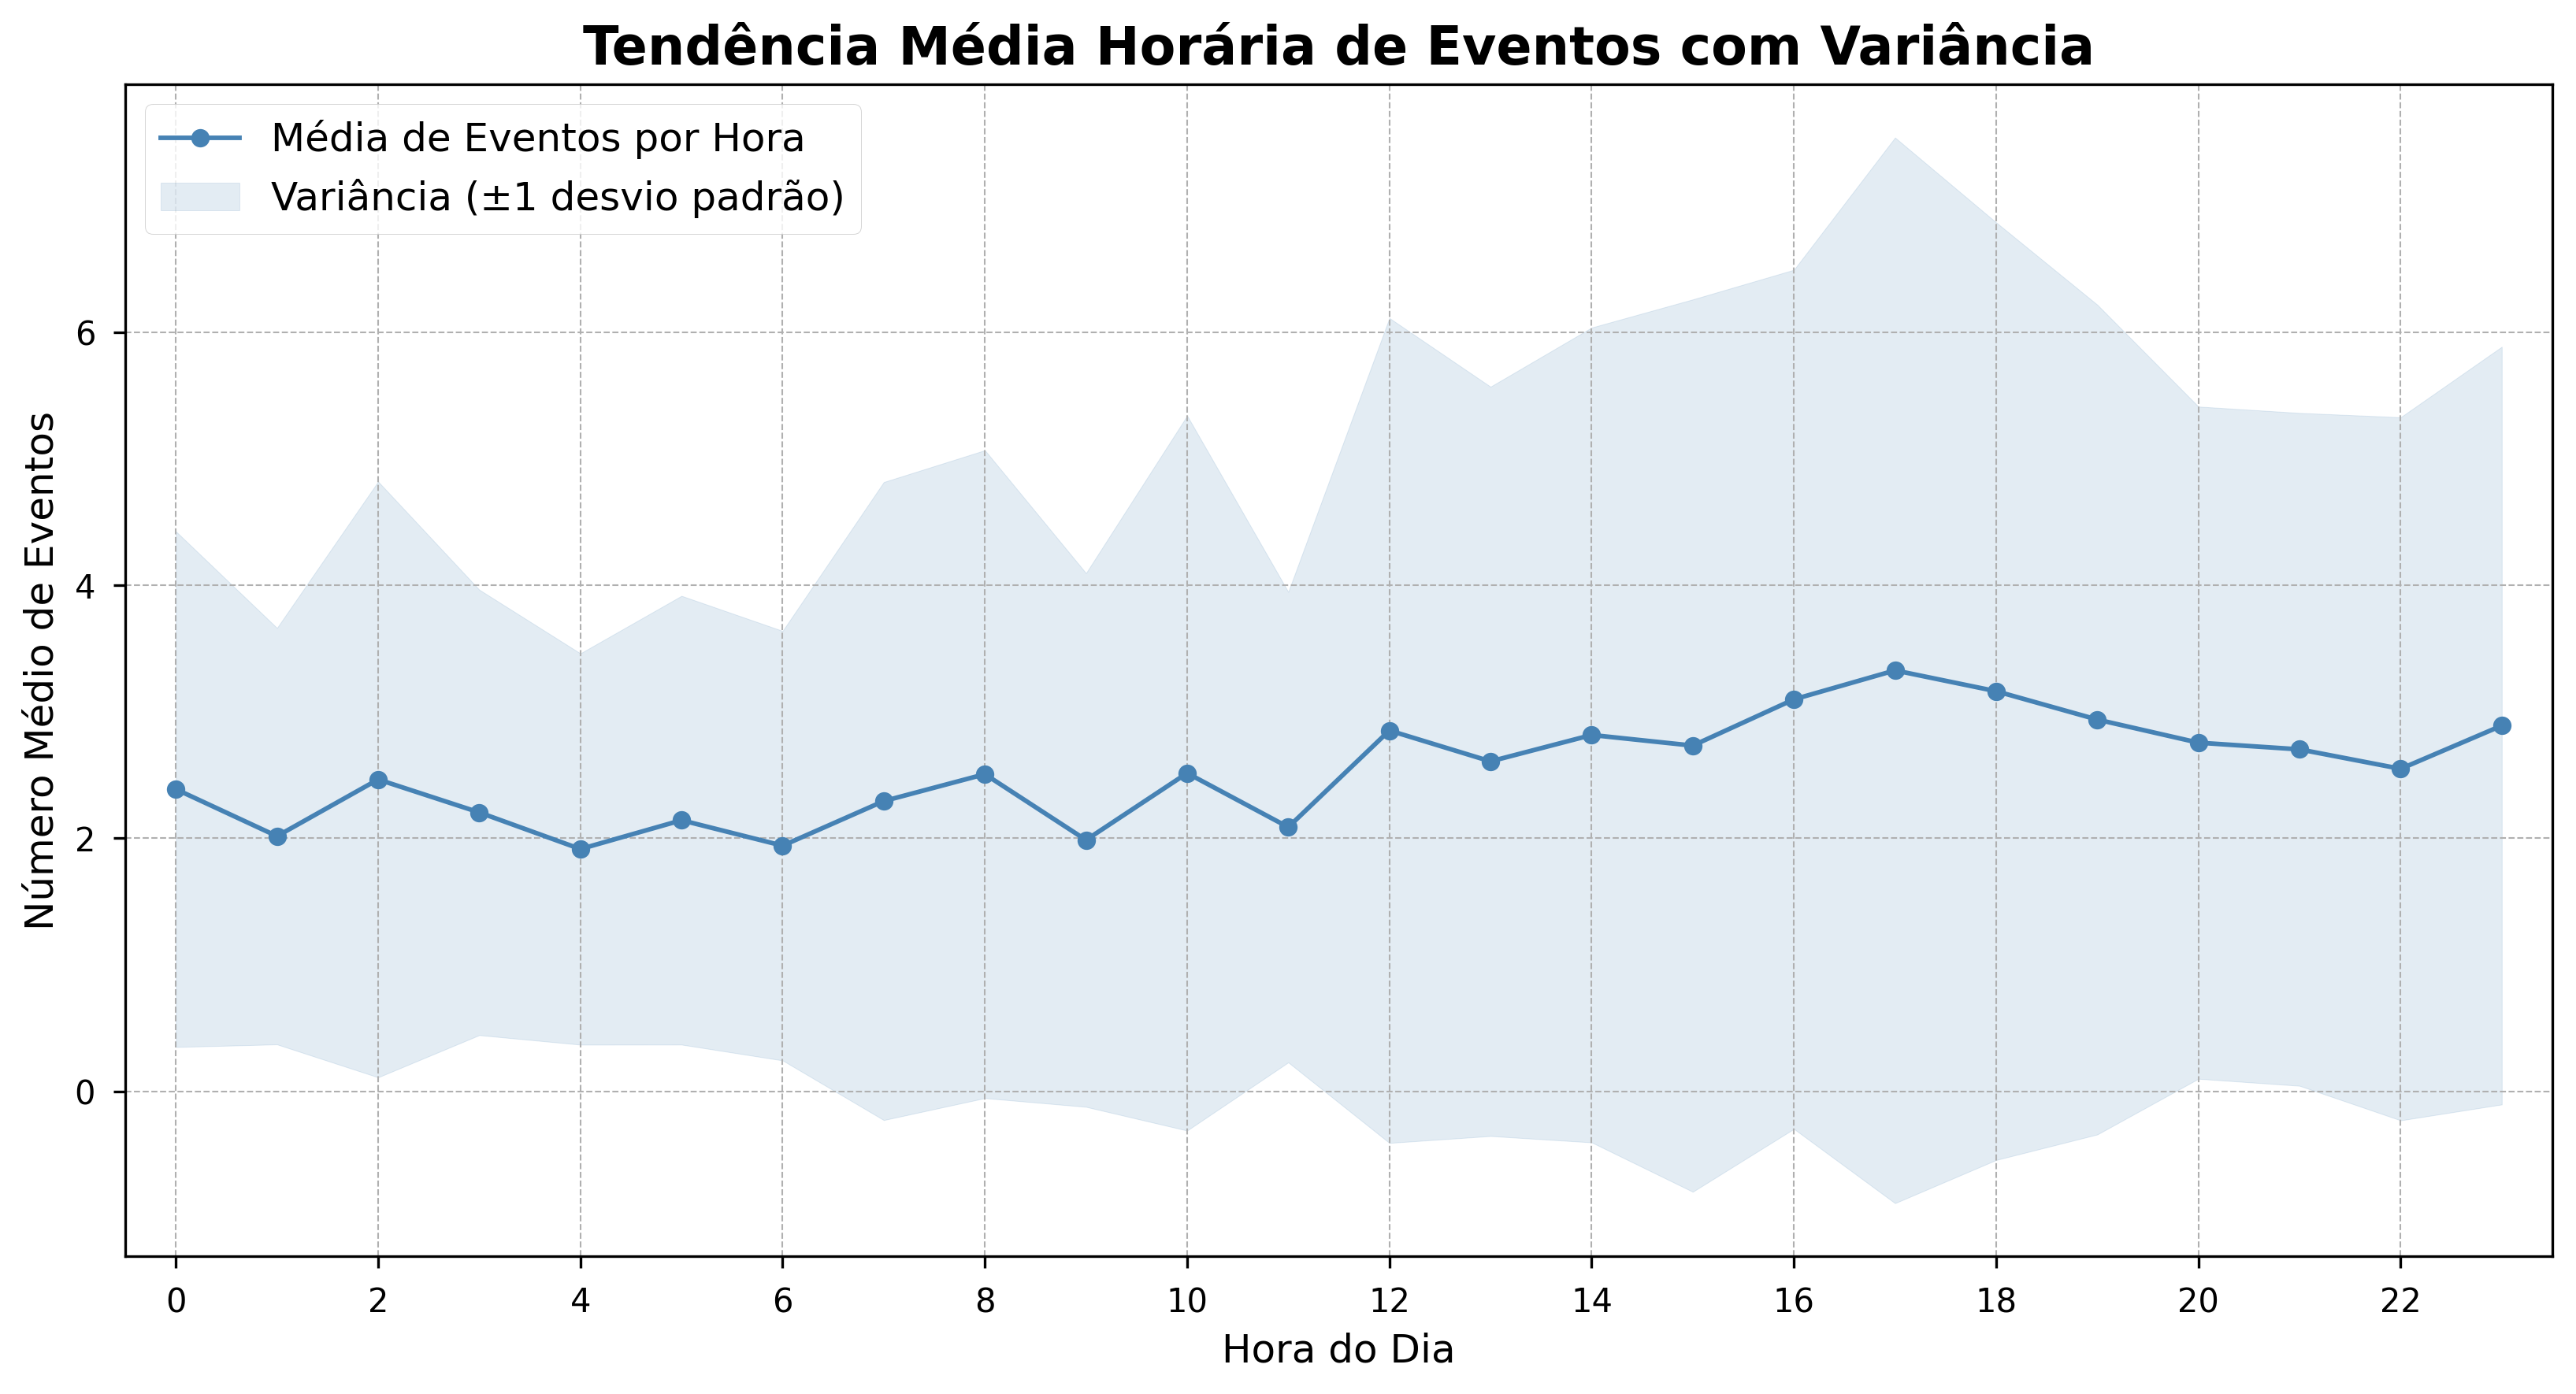

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico de Média Horária com Variância ---
fig, ax = plt.subplots(figsize=(11, 6))

# Linha da média
ax.plot(hourly_stats['hour'], hourly_stats['mean'],
        marker='o', linestyle='-', color='steelblue', label='Média de Eventos por Hora')

# Banda de variância (±1 desvio padrão)
ax.fill_between(hourly_stats['hour'], hourly_stats['lower'], hourly_stats['upper'],
                color='steelblue', alpha=0.15, label='Variância (±1 desvio padrão)')

# Estilização
ax.set_title('Tendência Média Horária de Eventos com Variância', fontsize=16, weight='bold')
ax.set_xlabel('Hora do Dia', fontsize=12)
ax.set_ylabel('Número Médio de Eventos', fontsize=12)
ax.grid(True, which='major', linestyle='--', linewidth=0.5)
ax.legend(loc='upper left', fontsize=12)
ax.set_xticks(range(0, 24, 2)) # Ticks a cada 2 horas
ax.set_xlim(-0.5, 23.5)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size


plt.tight_layout()
plt.show()

### Seasonal Flood Ocurrence Count and Percentage

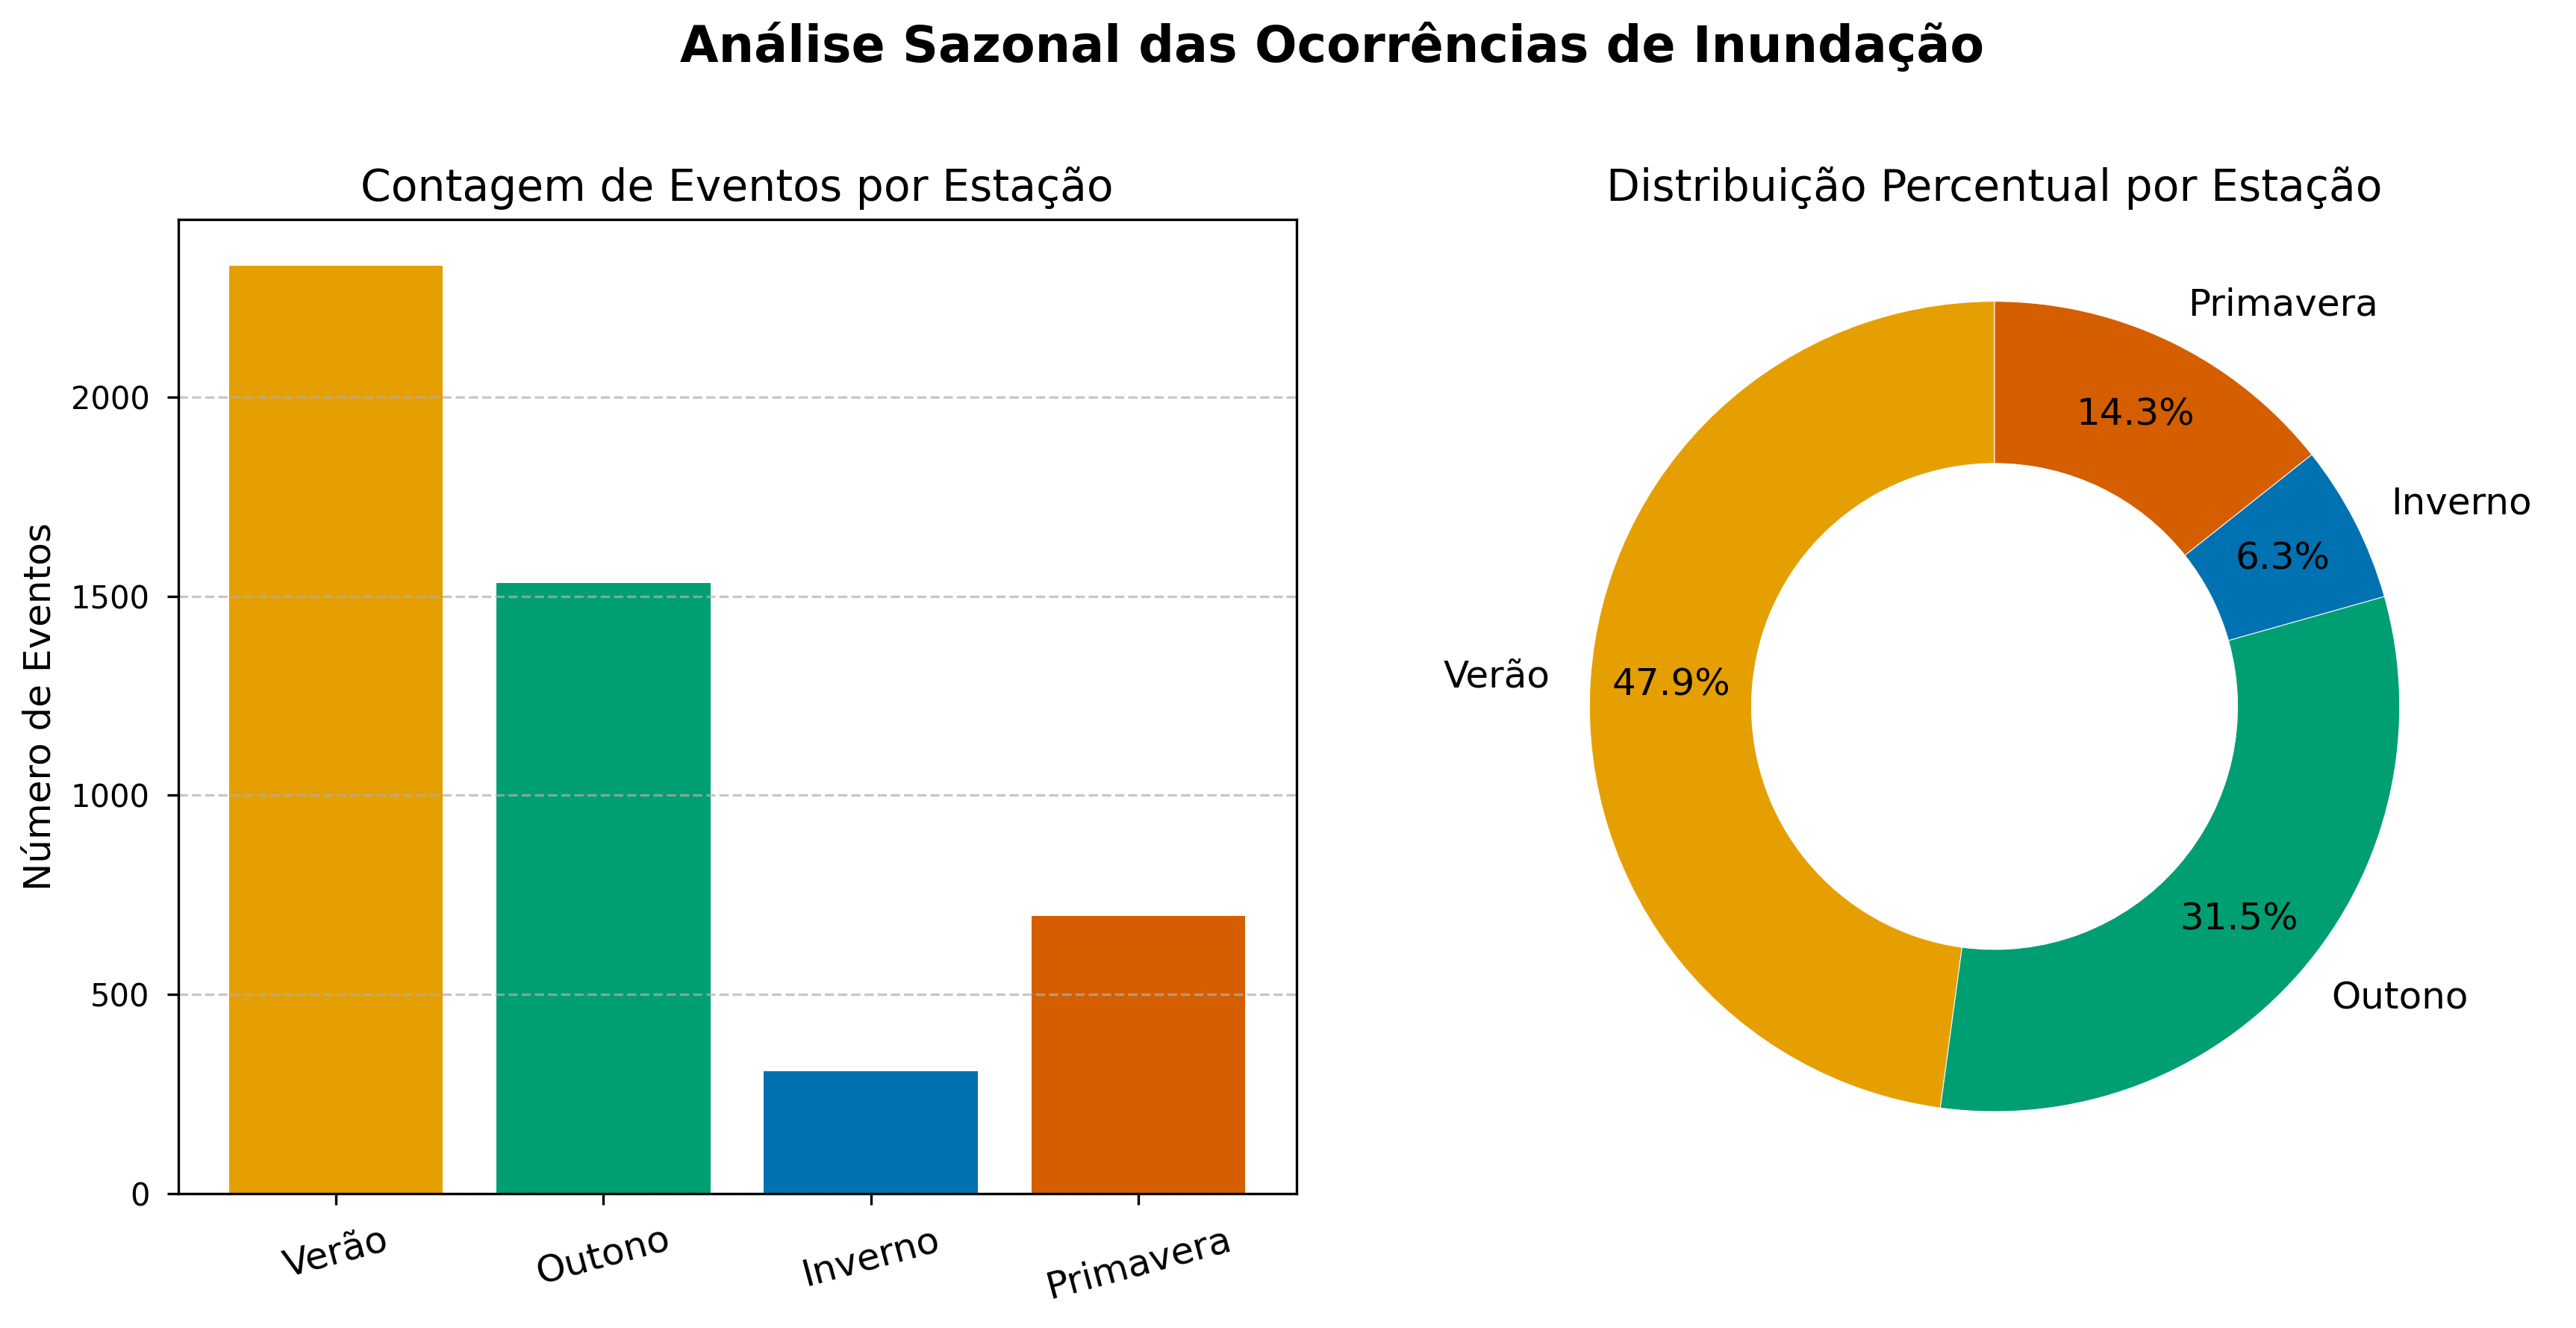

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

## ----- Events per Season (2) -----

# Function to assign meteorological seasons
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

# Assign season to each occurrence
ocorrencias['season'] = ocorrencias['data_inicio'].apply(get_season)

# Count events per season
events_per_season = (
    ocorrencias['season']
    .value_counts()
    .reindex(['Summer', 'Autumn', 'Winter', 'Spring'])
    .reset_index()
)
events_per_season.columns = ['season', 'count']

# ---

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# Preparar dados e traduzir
season_translation = {'Summer': 'Verão', 'Autumn': 'Outono', 'Winter': 'Inverno', 'Spring': 'Primavera'}
events_per_season['season_pt'] = events_per_season['season'].map(season_translation)

# --- Gráfico de Barras e Pizza para Análise Sazonal ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Análise Sazonal das Ocorrências de Inundação', fontsize=16, weight='bold')

# Paleta de cores amigável para daltônicos
colors = ['#E69F00', '#009E73', '#0072B2', '#D55E00']
season_order_pt = ['Verão', 'Outono', 'Inverno', 'Primavera']
events_per_season_sorted = events_per_season.set_index('season_pt').loc[season_order_pt]

# Gráfico de Barras (ax1)
ax1.bar(events_per_season_sorted.index, events_per_season_sorted['count'], color=colors)
ax1.set_title('Contagem de Eventos por Estação', fontsize=14)
ax1.set_ylabel('Número de Eventos', fontsize=12)
ax1.tick_params(axis='x', rotation=15, labelsize=12)  # Increase x-axis tick label size
ax1.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico de Pizza (ax2)
ax2.pie(events_per_season_sorted['count'], labels=events_per_season_sorted.index,
        autopct='%1.1f%%', pctdistance=0.8, startangle=90, colors=colors,
        wedgeprops=dict(width=0.4, edgecolor='w')) # Estilo rosca (donut)
ax2.set_title('Distribuição Percentual por Estação', fontsize=14)
ax2.axis('equal') # Garante que a pizza seja um círculo

# Increase pie chart label size manually
for text in ax2.texts:
    text.set_fontsize(12)
    
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajuste para o título principal
plt.show()

### Histogram of Event Durations

- Show the distribution of event durations overall and by event type.

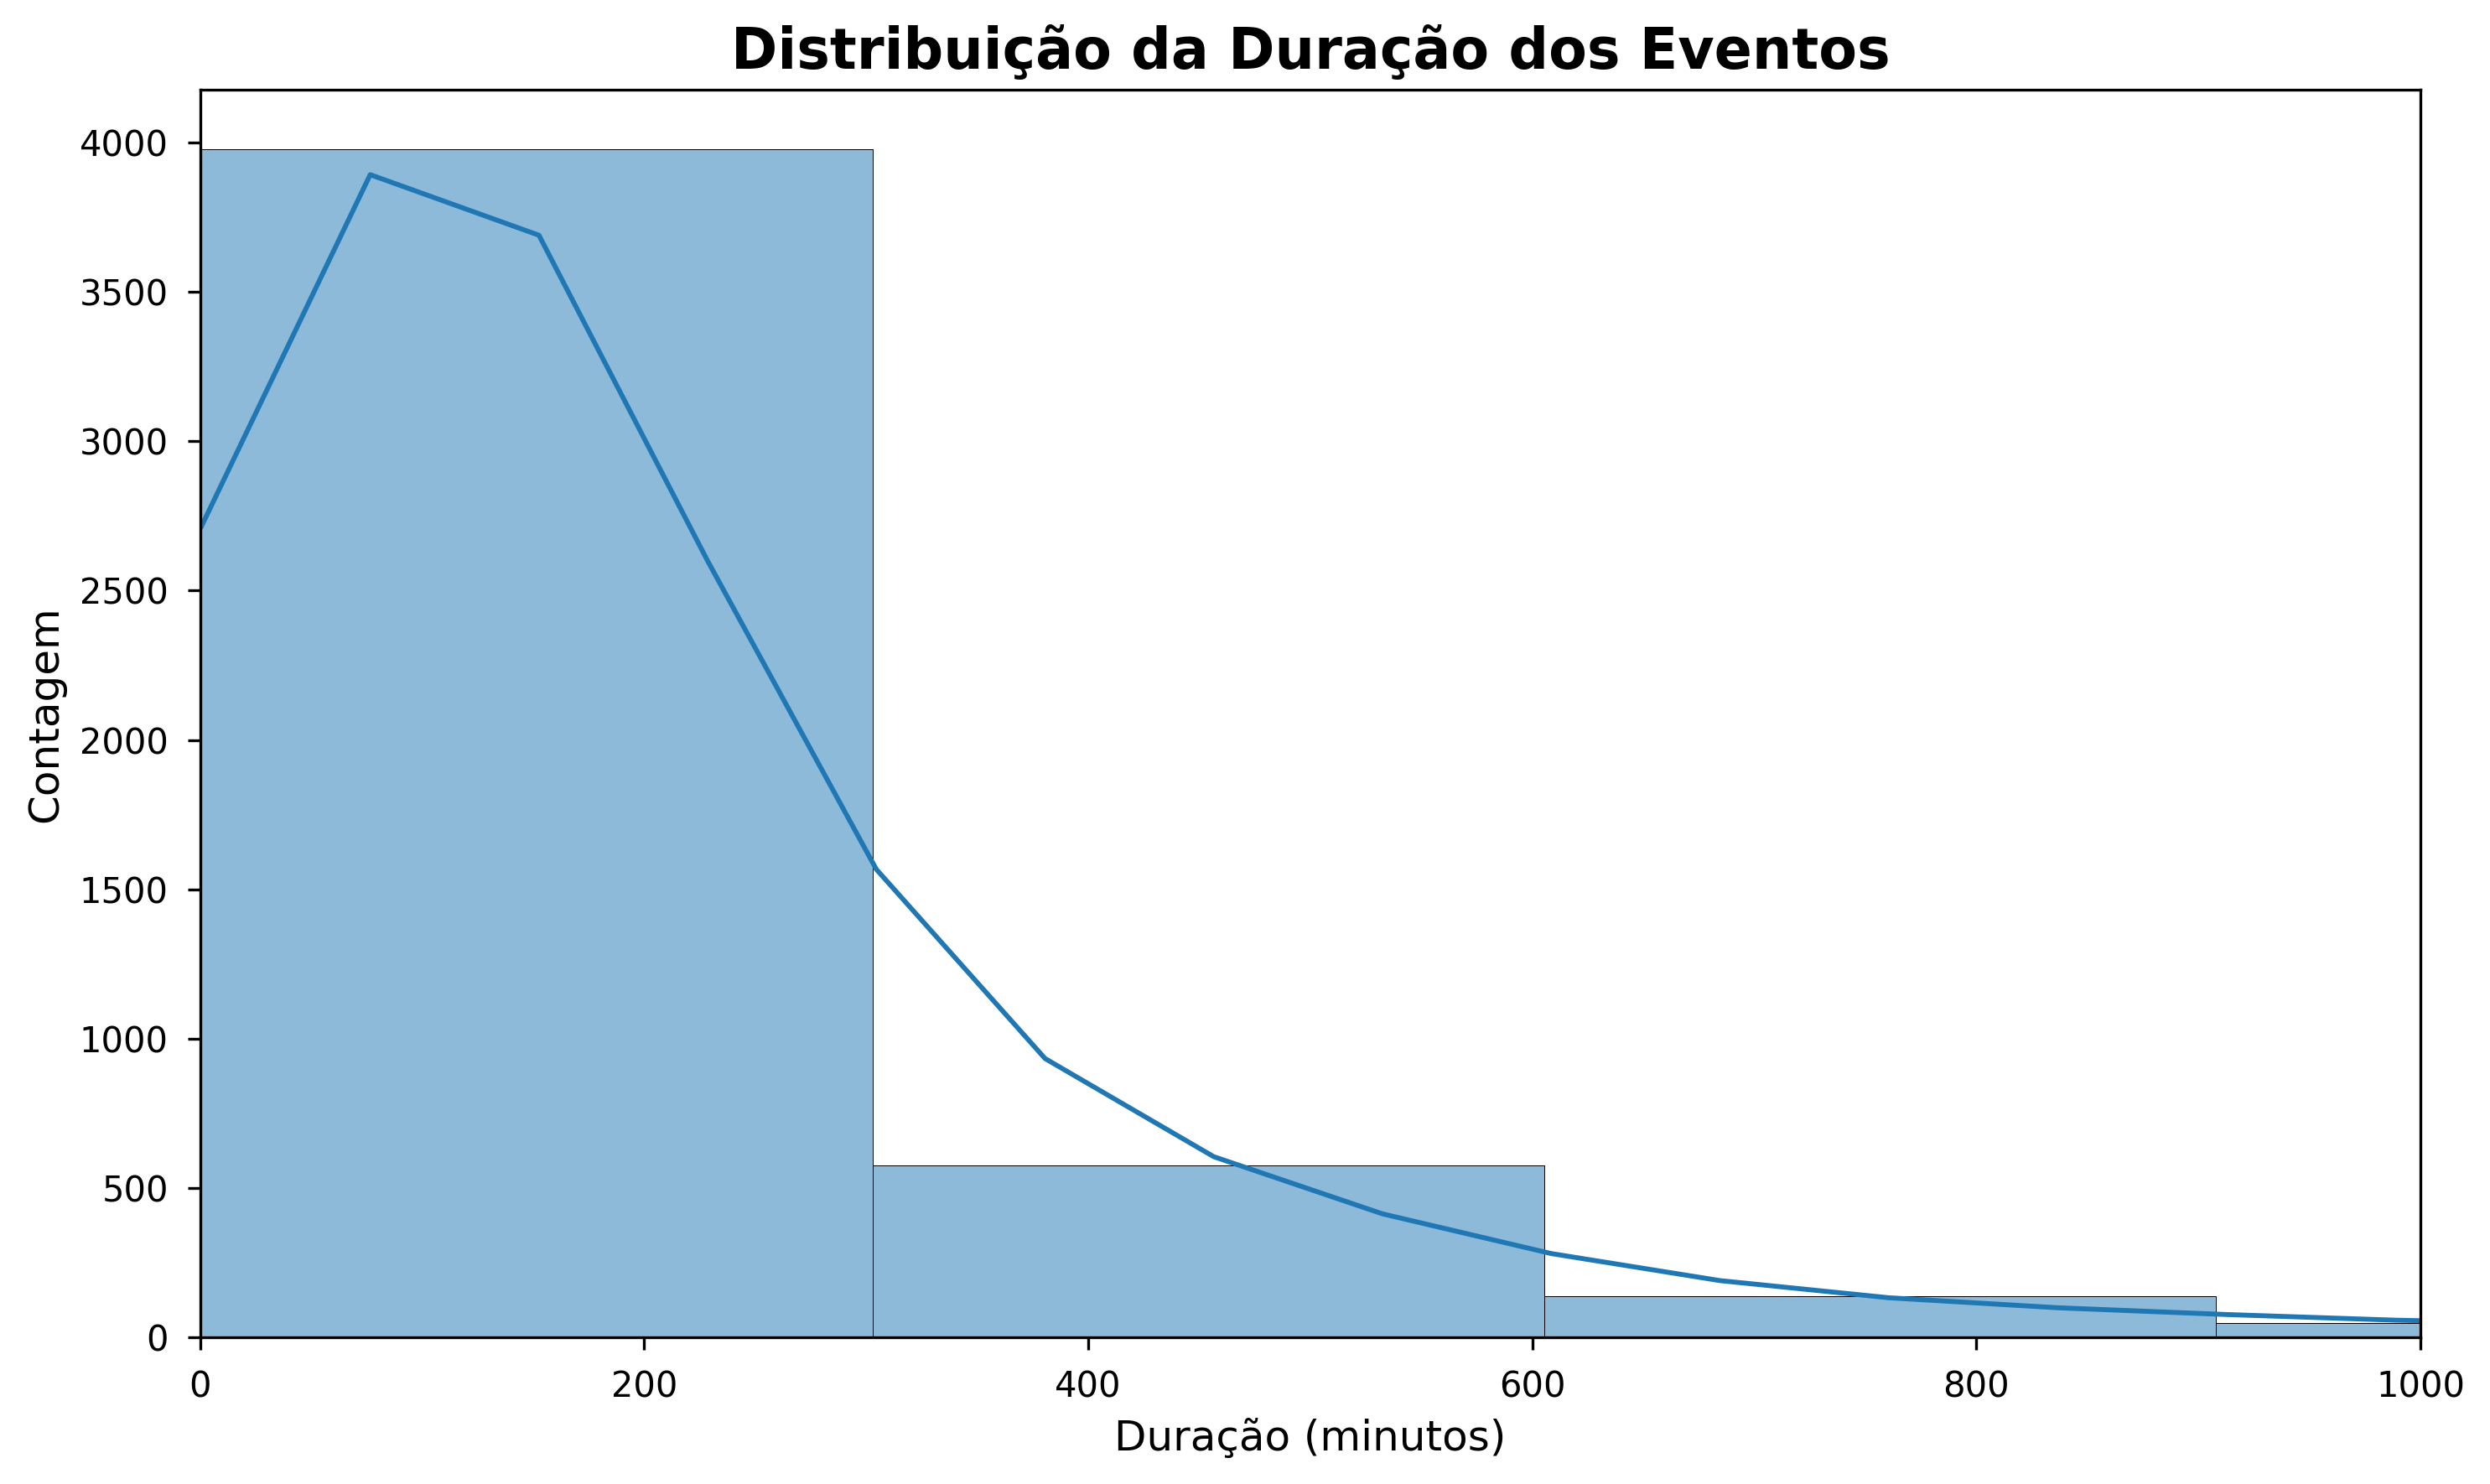

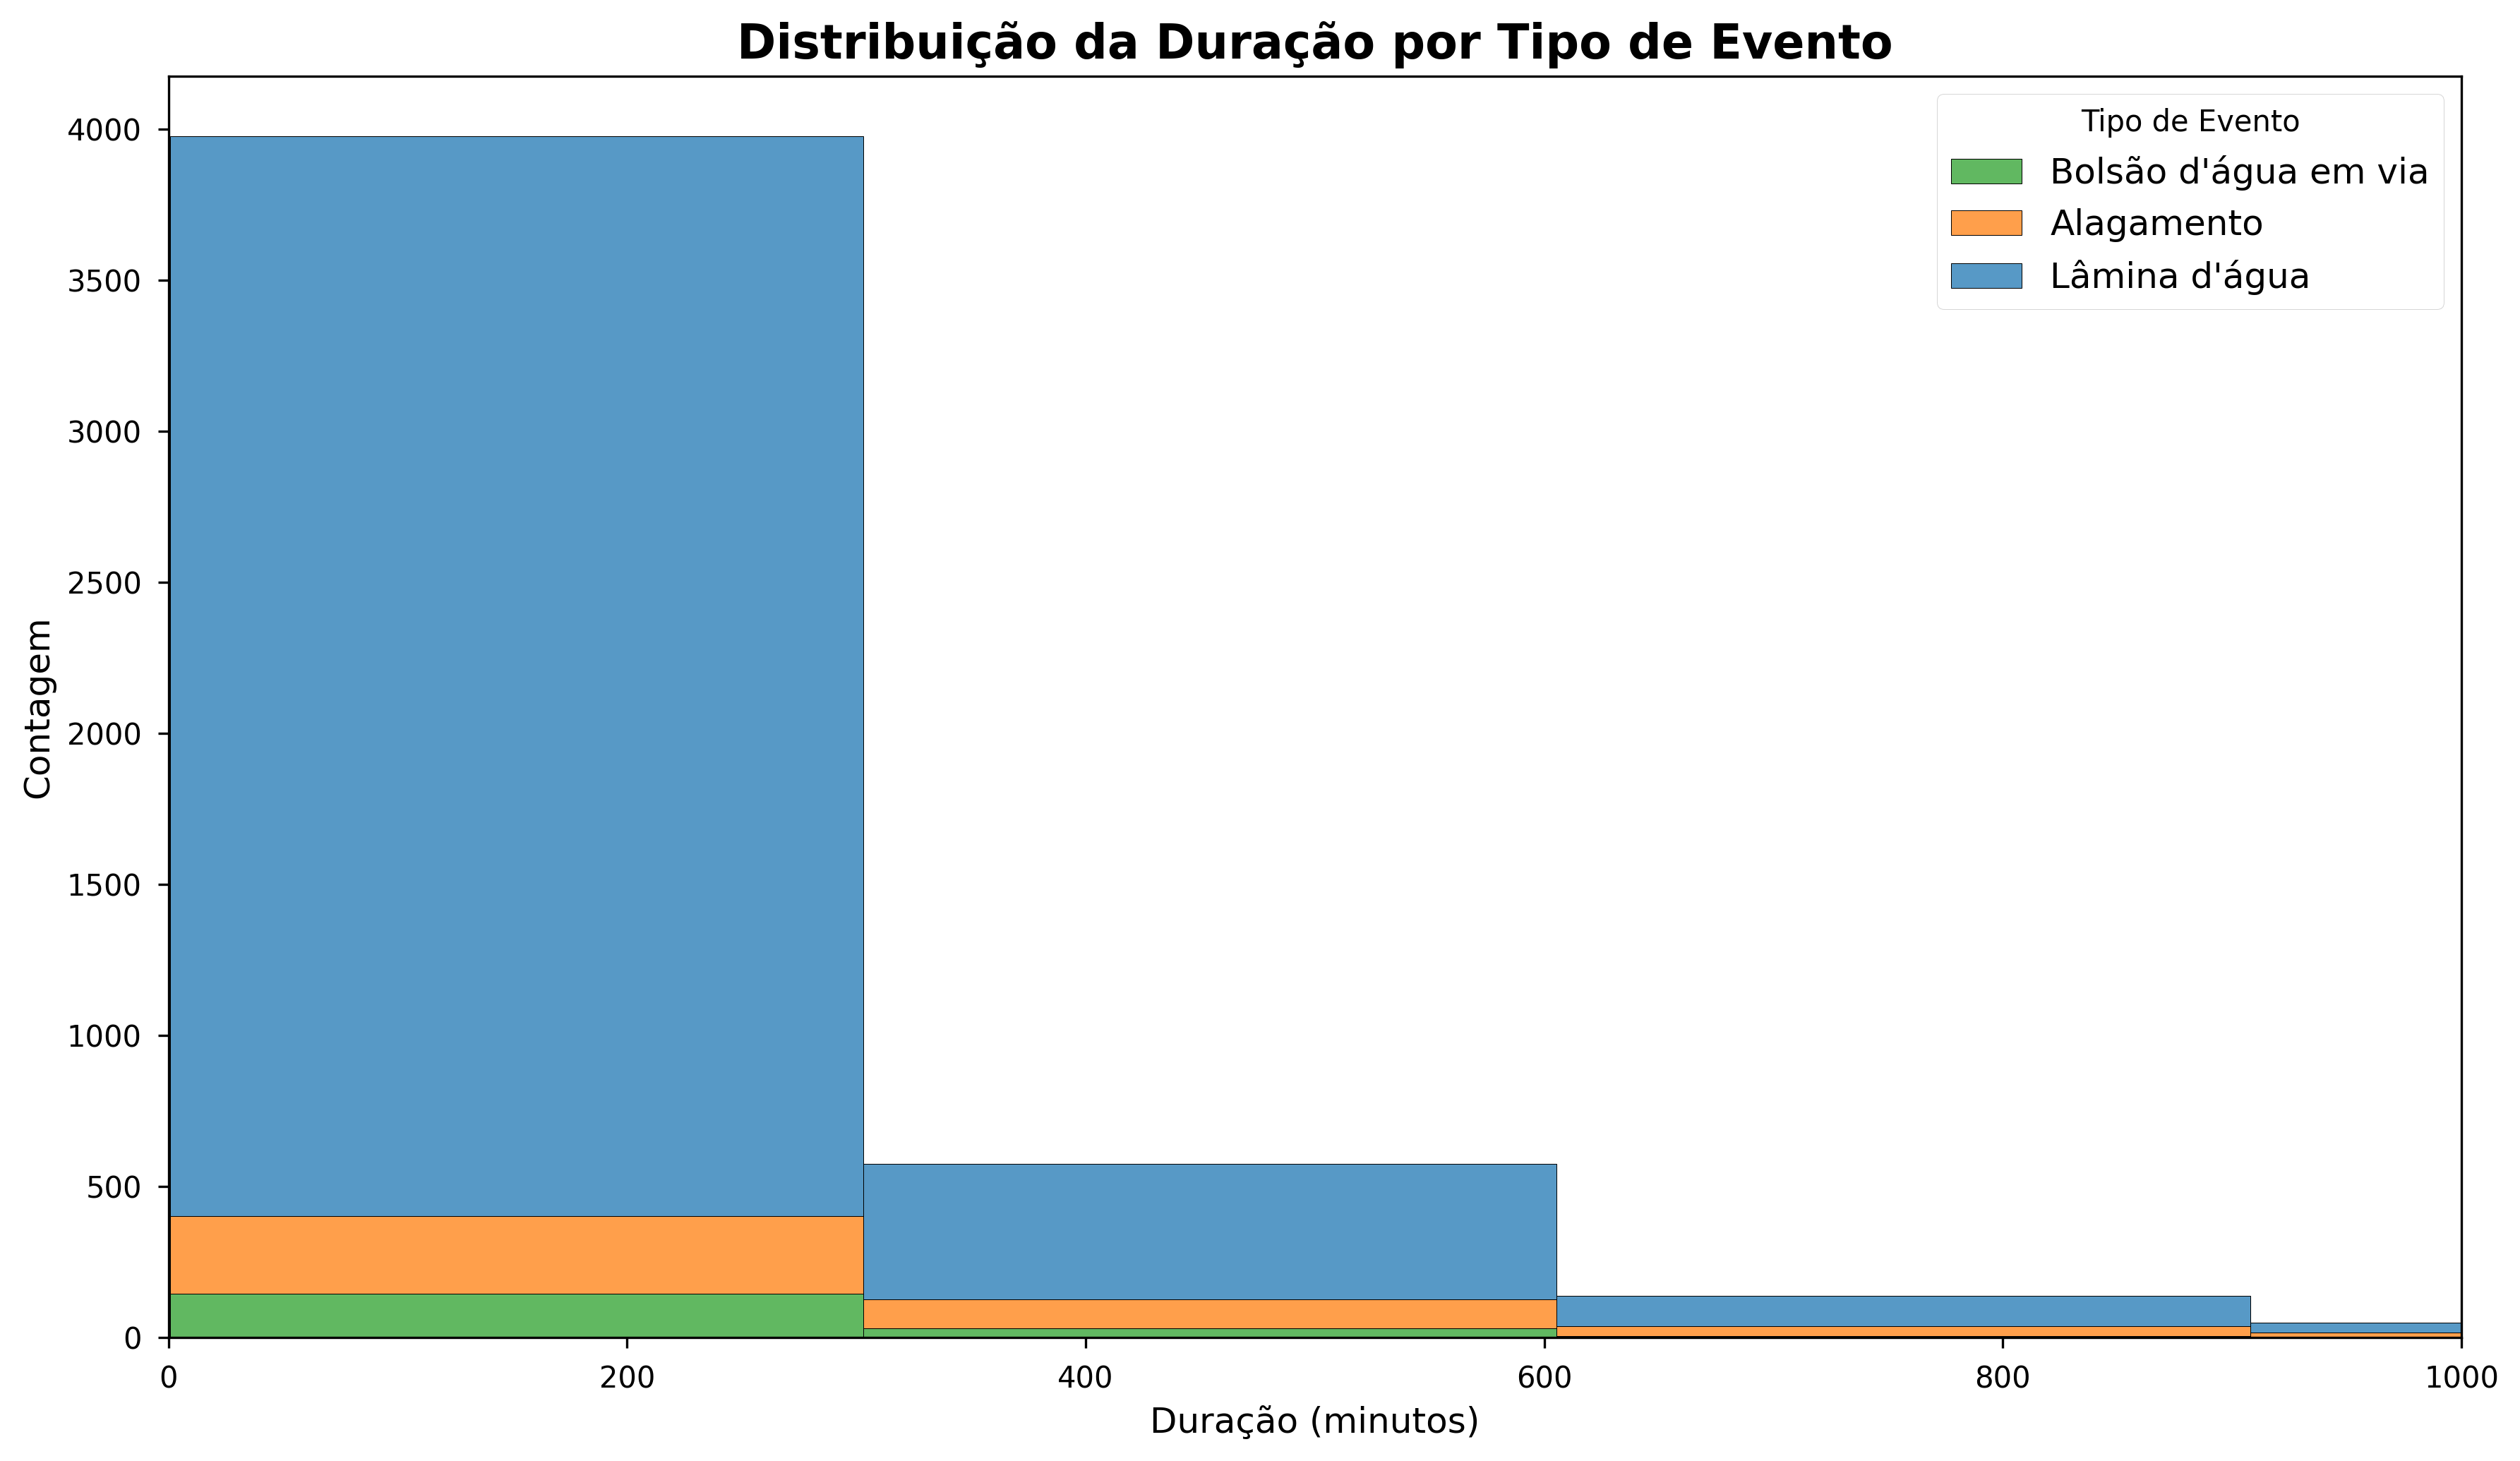

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução para publicações
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Histograma 1: Distribuição Geral da Duração ---
plt.figure(figsize=(10, 6))
ax1 = sns.histplot(data=ocorrencias, x='duration_minutes', bins=50, kde=True)
ax1.set_title('Distribuição da Duração dos Eventos', fontsize=16, weight='bold')
ax1.set_xlabel('Duração (minutos)', fontsize=12)
ax1.set_ylabel('Contagem', fontsize=12)
ax1.set_xlim(0, 1000) # Limite para melhor visualização, como no original
ax1.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax1.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()


# --- Histograma 2: Distribuição da Duração por Tipo de Evento ---
plt.figure(figsize=(12, 7))
ax2 = sns.histplot(data=ocorrencias, x='duration_minutes', hue='tipo',
                   bins=50, multiple='stack', kde=False) # 'stack' para empilhar
ax2.set_title('Distribuição da Duração por Tipo de Evento', fontsize=16, weight='bold')
ax2.set_xlabel('Duração (minutos)', fontsize=12)
ax2.set_ylabel('Contagem', fontsize=12)
ax2.set_xlim(0, 1000)
ax2.legend(title='Tipo de Evento', labels=ocorrencias['tipo'].unique(), fontsize=12)
ax2.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax2.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()

### Bar Charts

- Hourly Distribution: Count events by hour of the day.
- Weekly Distribution: Count events by day-of-week.

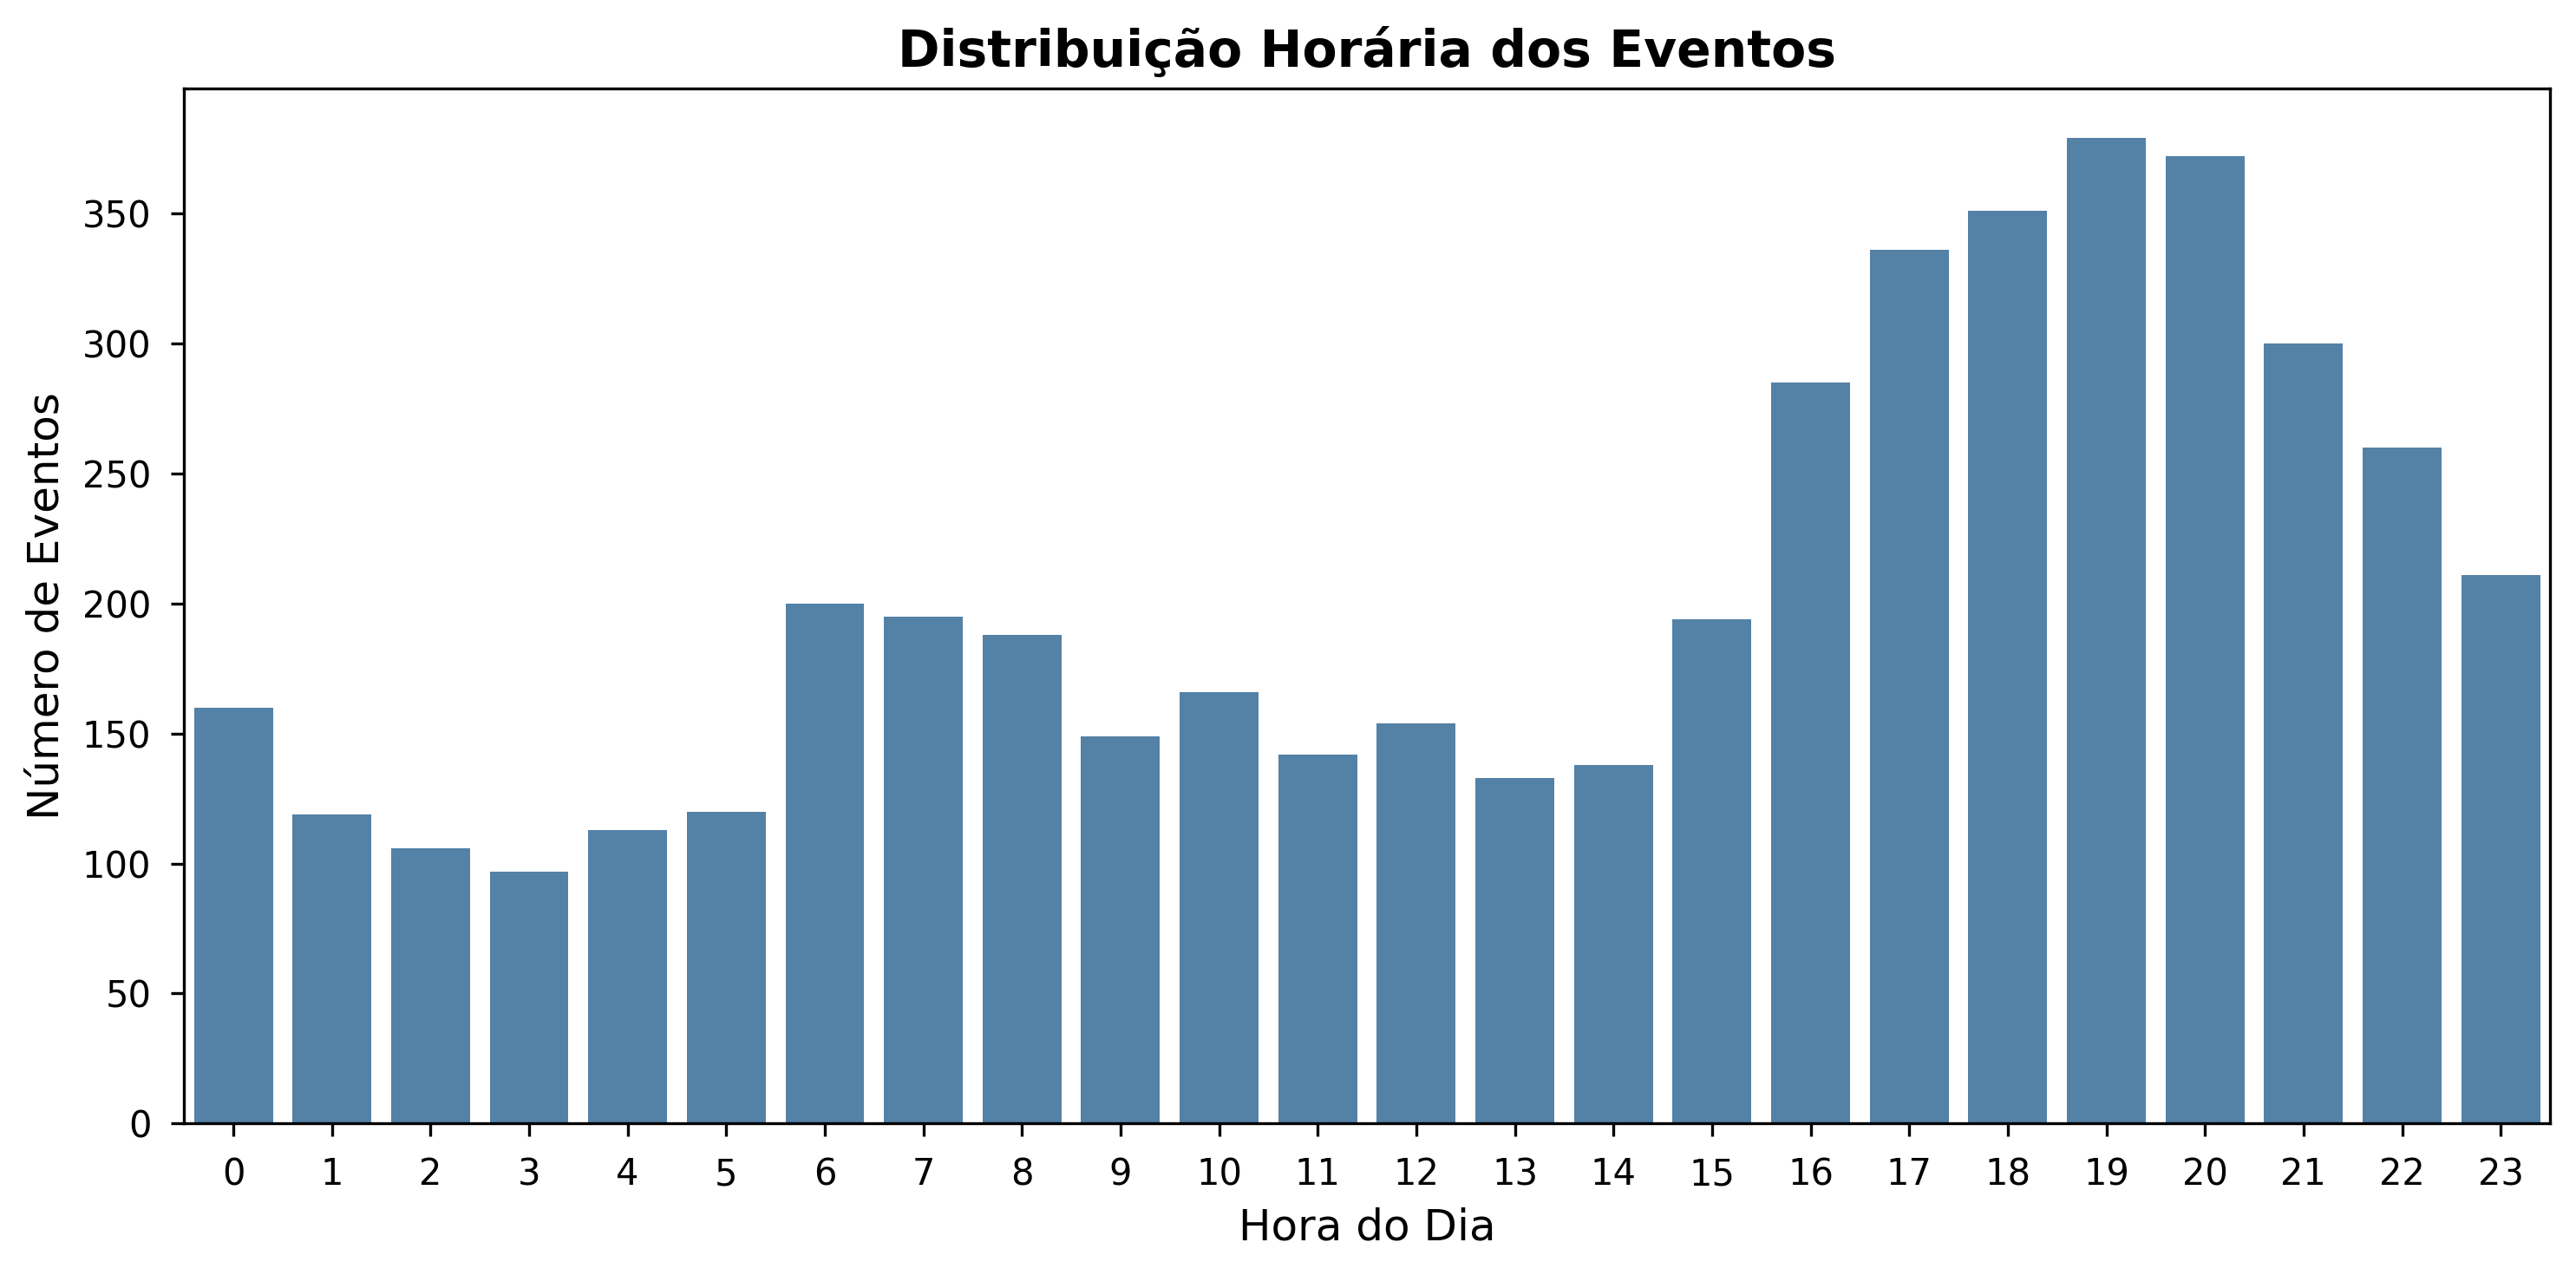

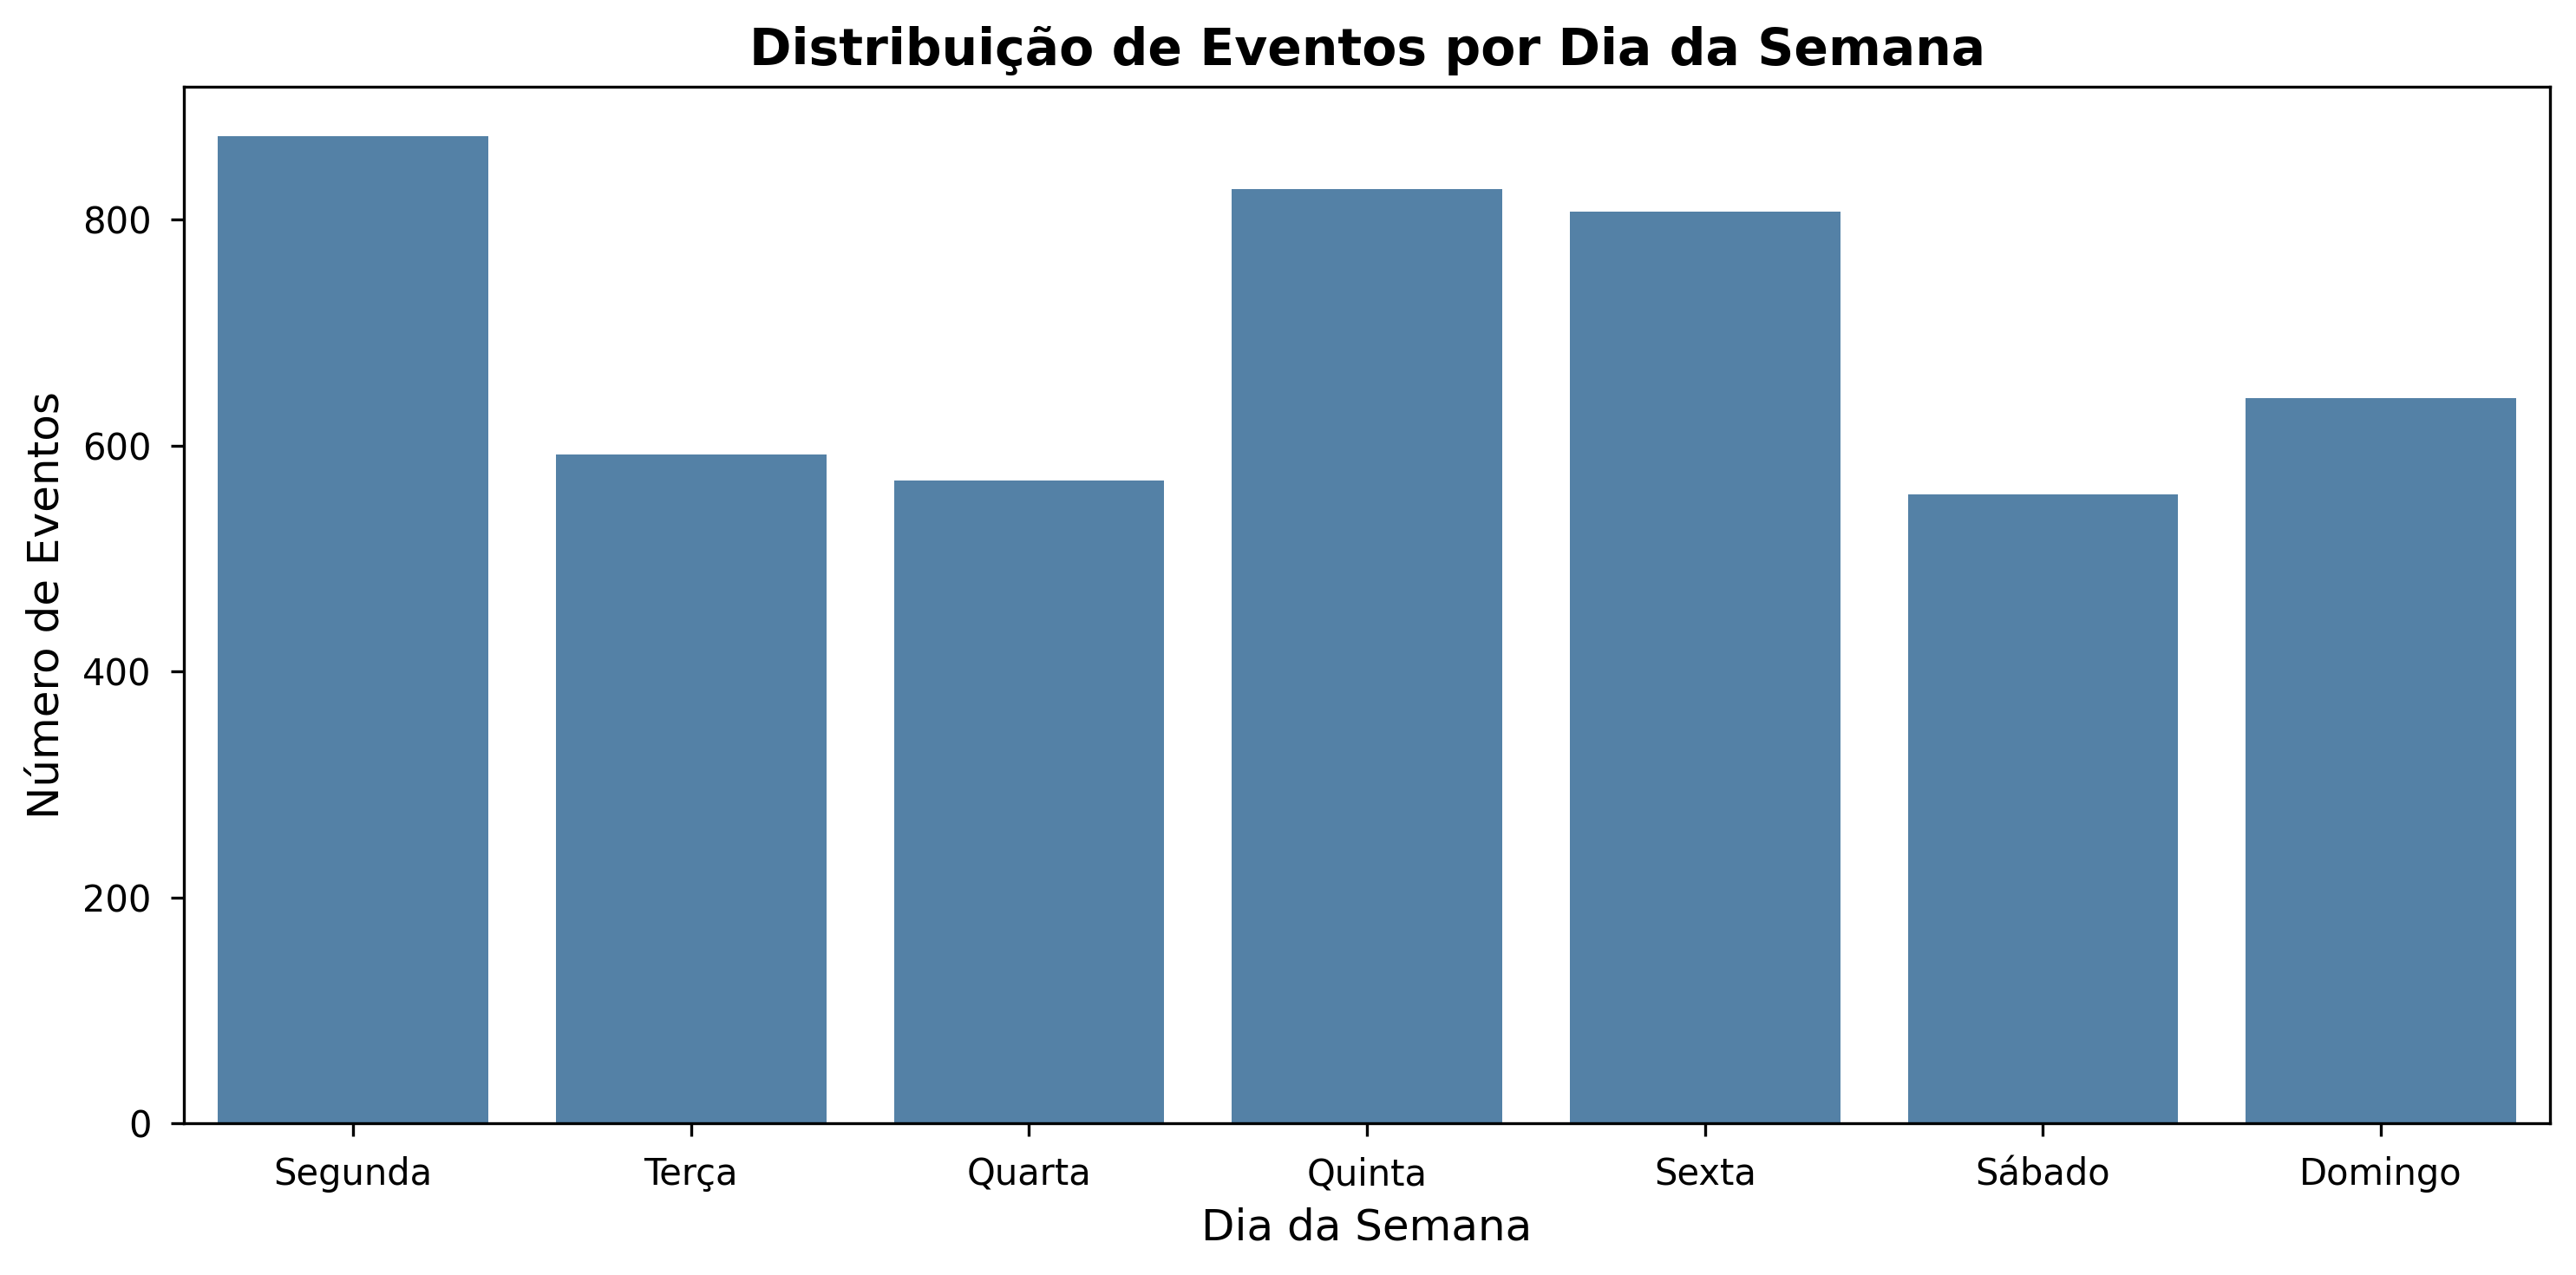

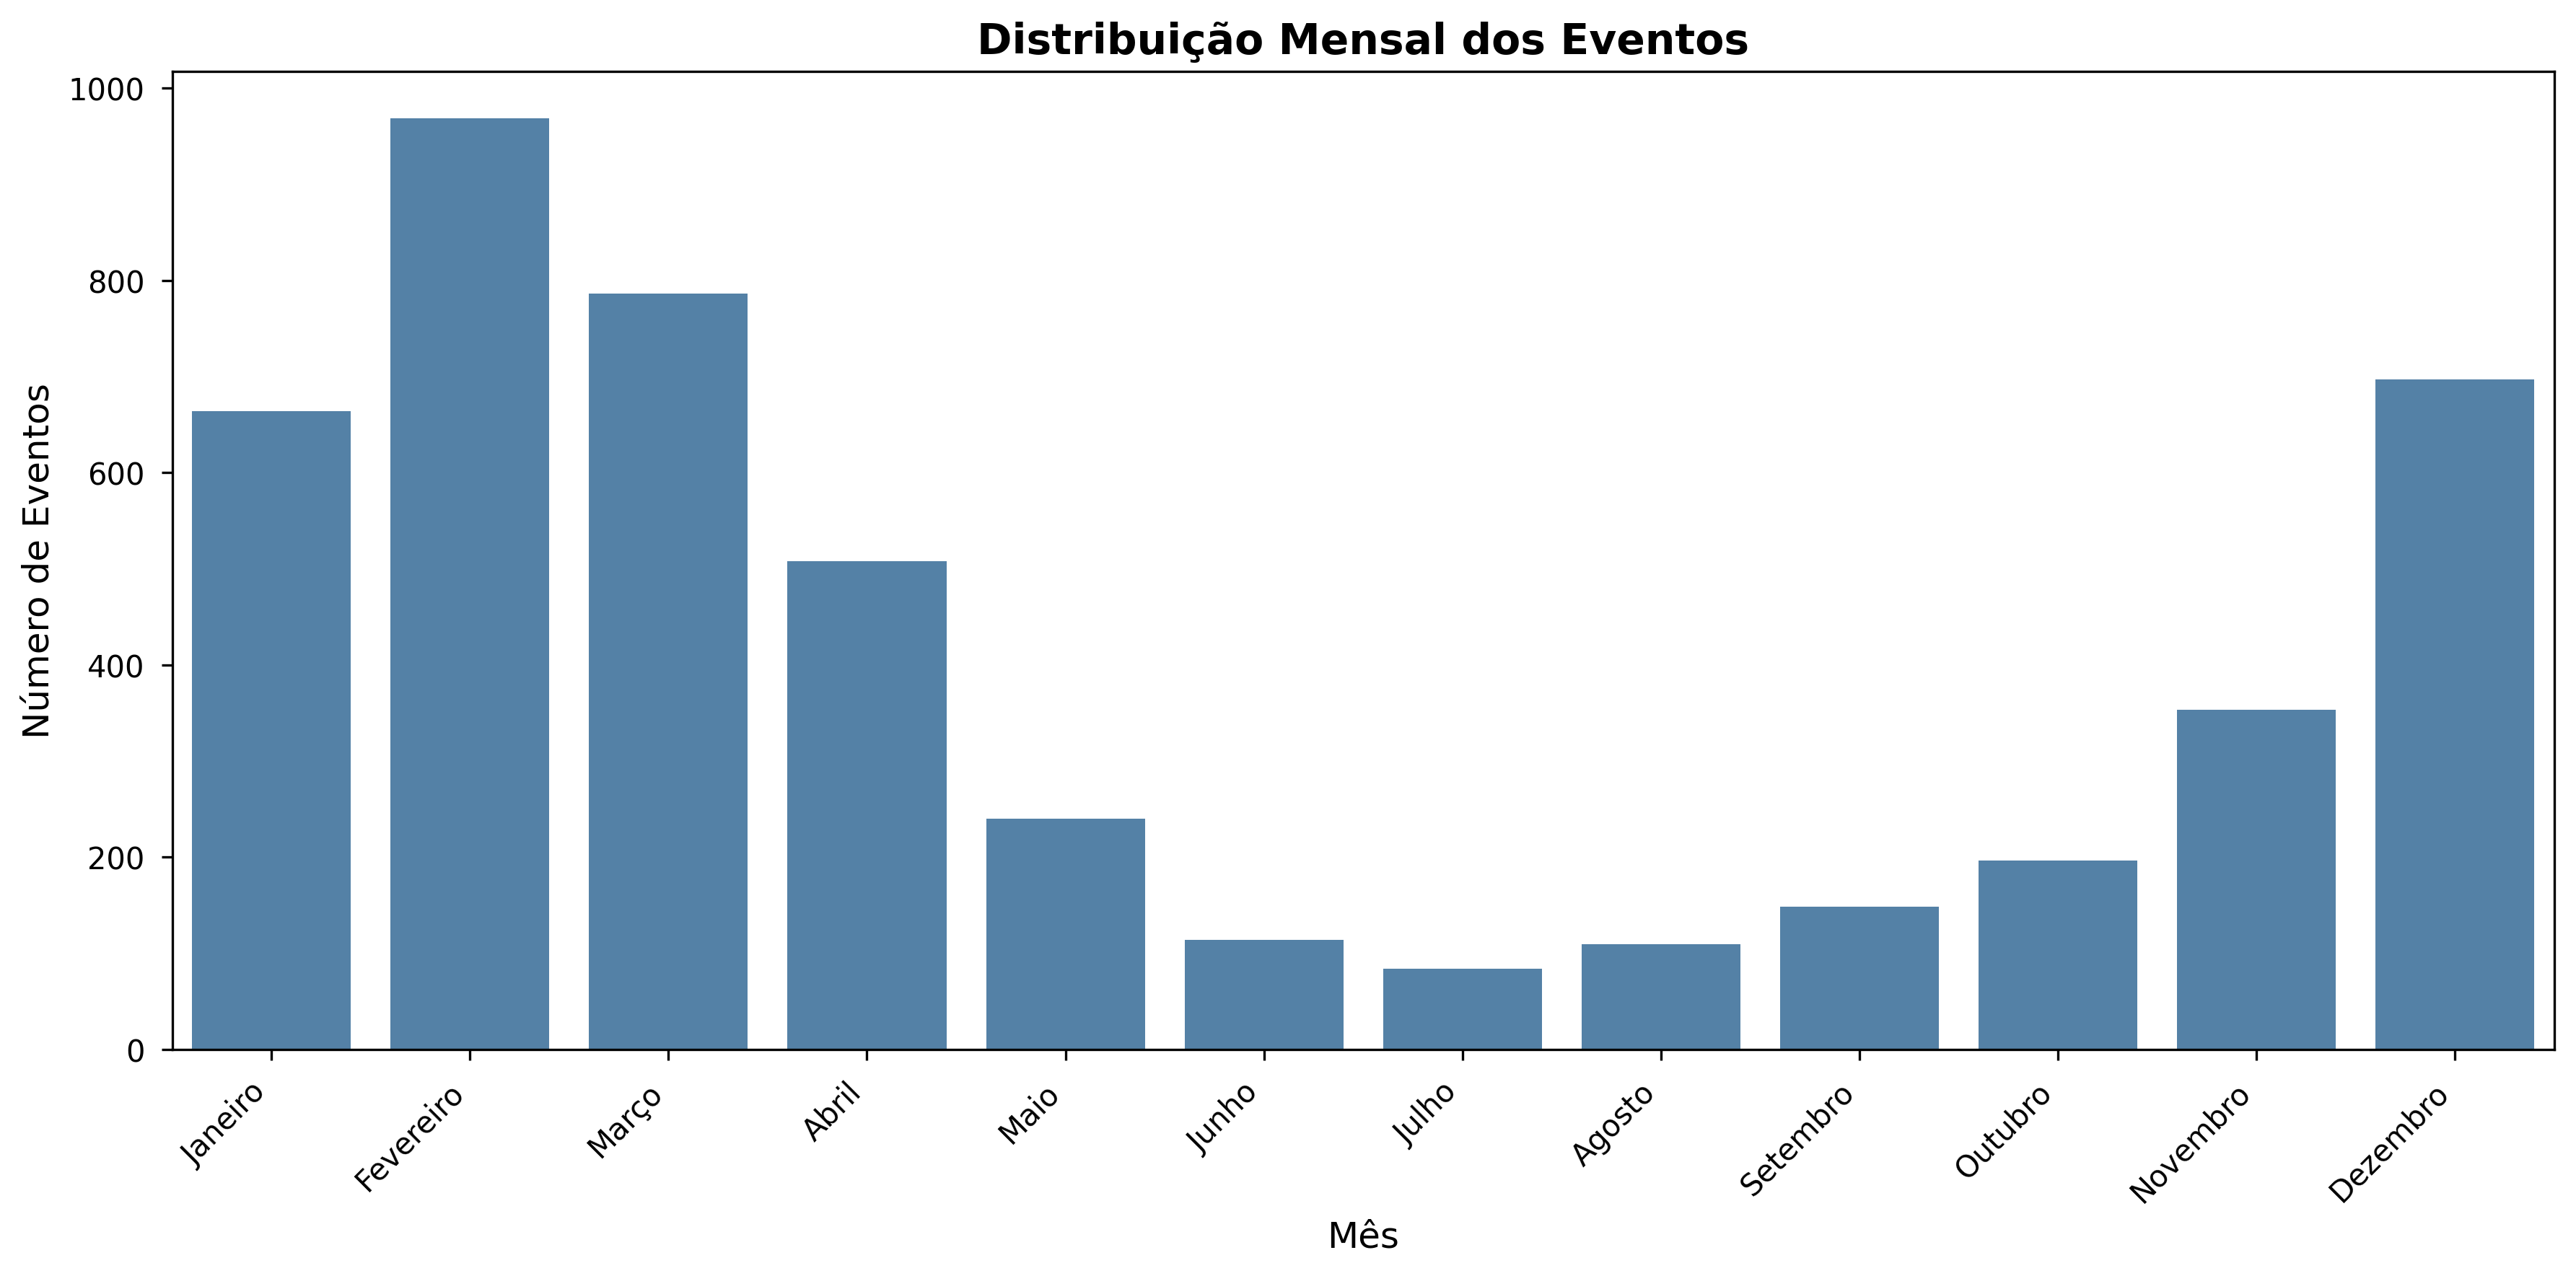

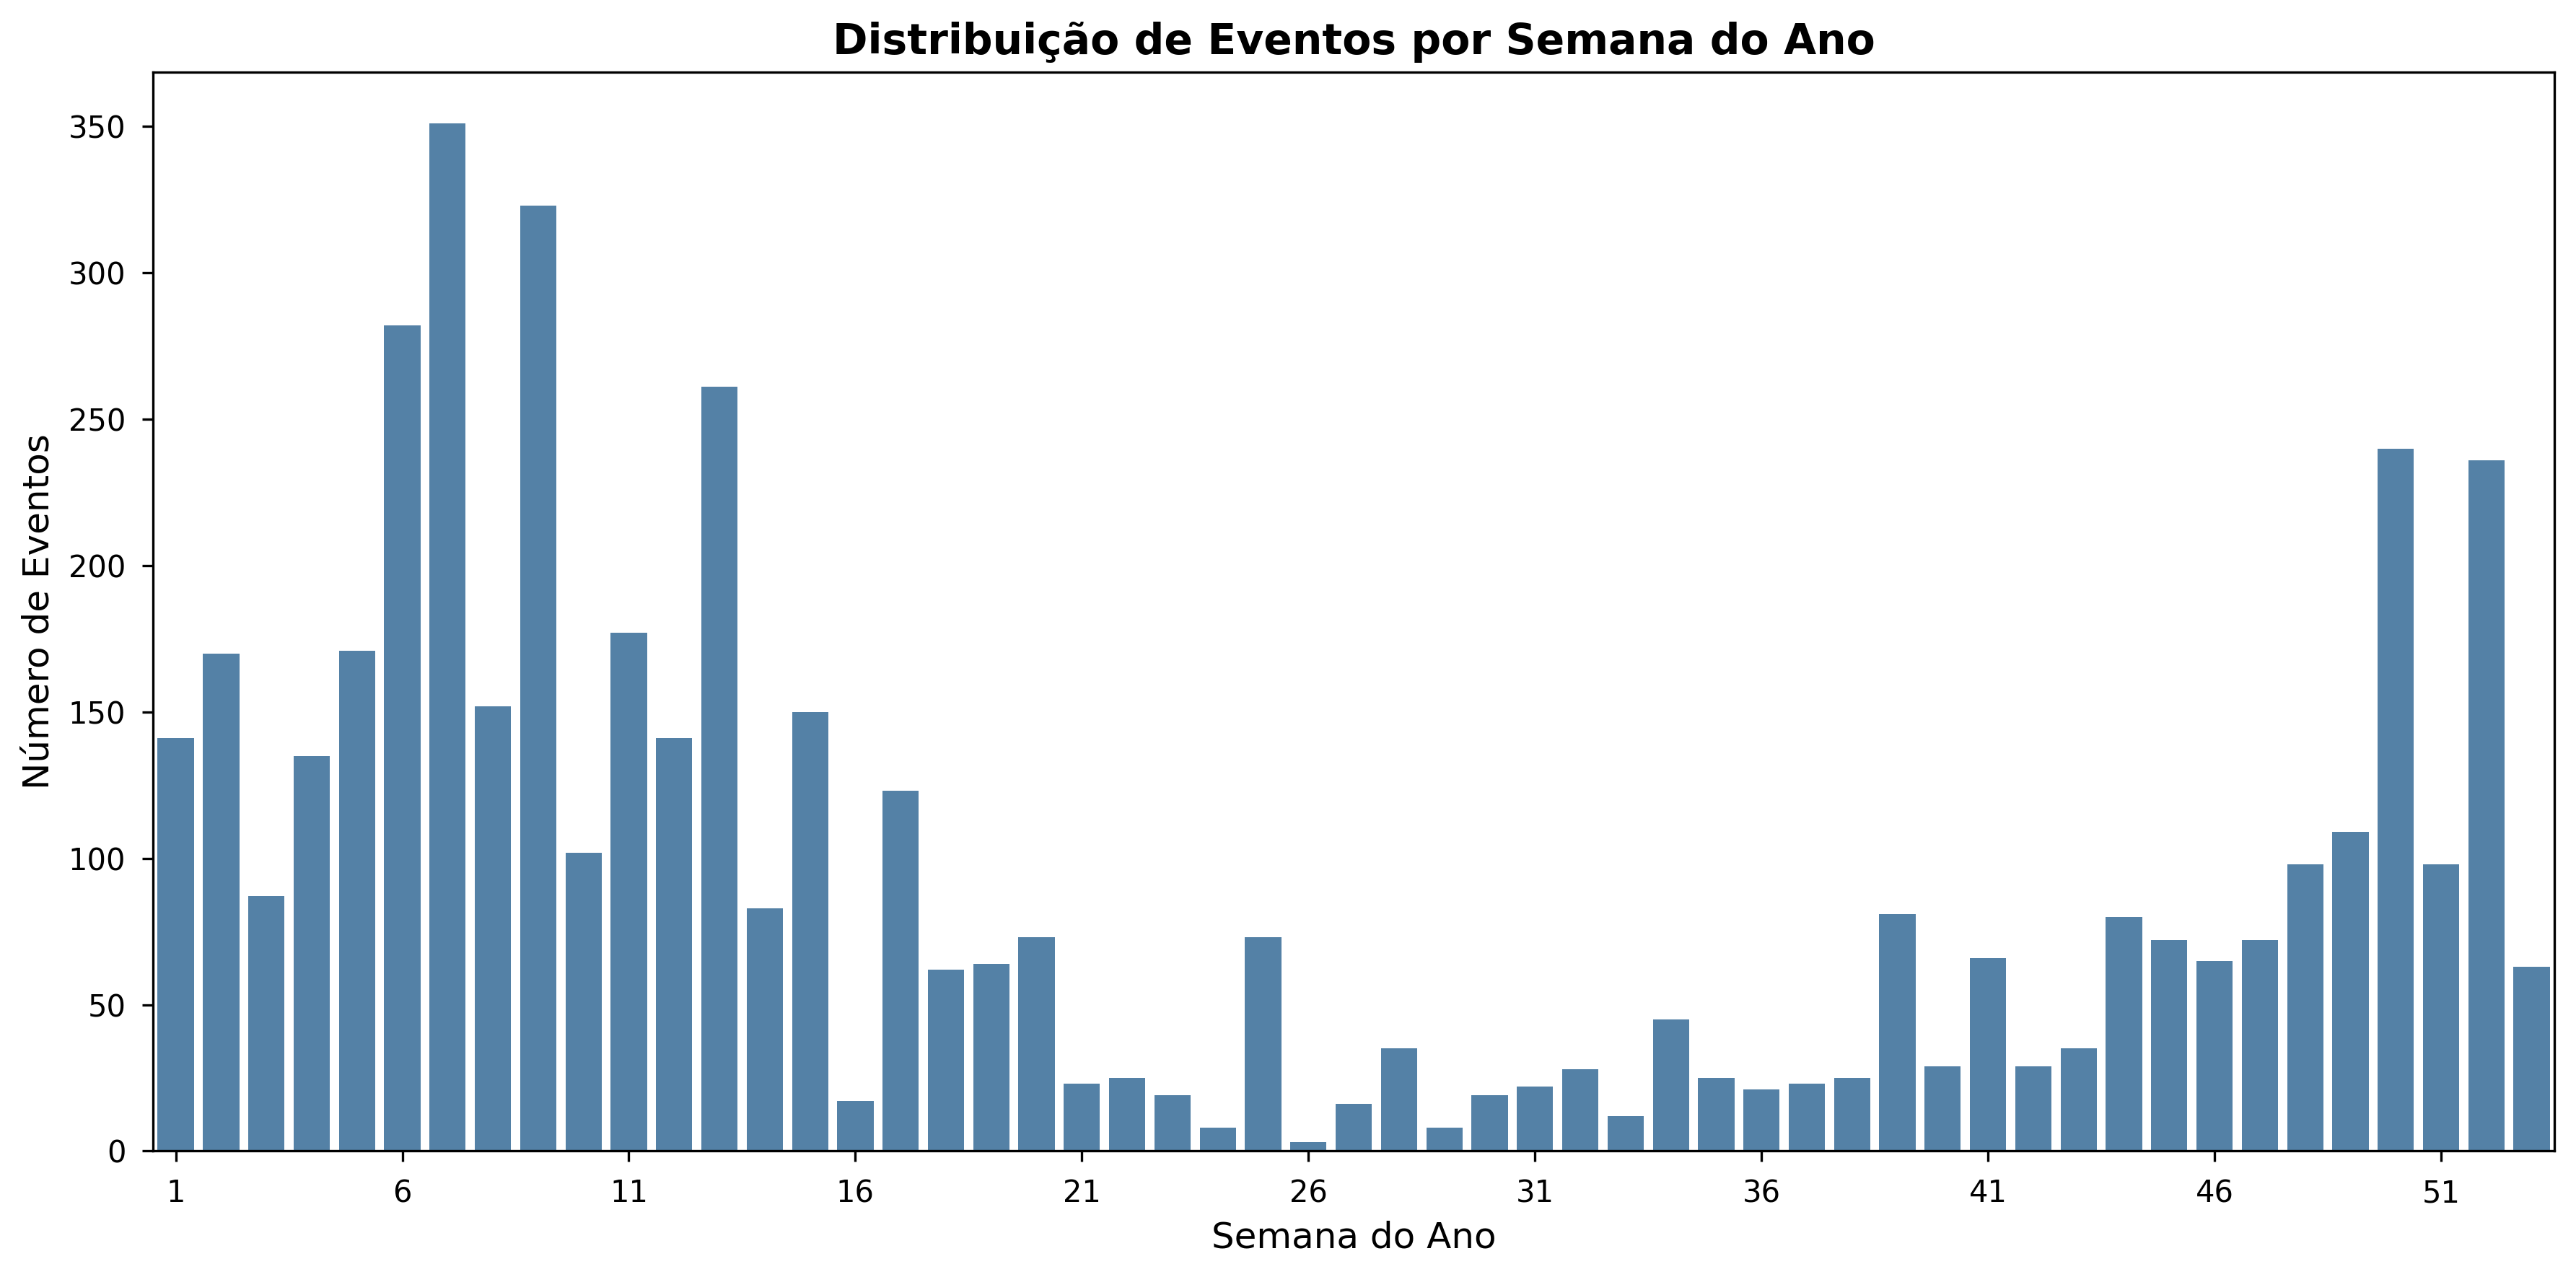

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico 1: Distribuição Horária ---
hourly_distribution = ocorrencias['hour_start'].value_counts().sort_index()
plt.figure(figsize=(10, 5))

ax1 = sns.barplot(x=hourly_distribution.index, y=hourly_distribution.values, color='steelblue')
ax1.set_title('Distribuição Horária dos Eventos', fontsize=14, weight='bold')
ax1.set_xlabel('Hora do Dia', fontsize=12)
ax1.set_ylabel('Número de Eventos', fontsize=12)
ax1.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax1.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()

# --- Gráfico 2: Distribuição por Dia da Semana ---
dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
day_order_en = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_distribution = ocorrencias['day_of_week'].value_counts().reindex(day_order_en)
plt.figure(figsize=(10, 5))
ax2 = sns.barplot(x=dias_pt, y=weekly_distribution.values, color='steelblue')
ax2.set_title('Distribuição de Eventos por Dia da Semana', fontsize=14, weight='bold')
ax2.set_xlabel('Dia da Semana', fontsize=12)
ax2.set_ylabel('Número de Eventos', fontsize=12)
ax2.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax2.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()

# --- Gráfico 3: Distribuição Mensal ---
meses_pt_full = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
                 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
month_order_en = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']
monthly_distribution = ocorrencias['month'].value_counts().sort_index()
monthly_distribution.index = month_order_en

plt.figure(figsize=(12, 6))
ax3 = sns.barplot(x=meses_pt_full, y=monthly_distribution.values, color='steelblue')
ax3.set_title('Distribuição Mensal dos Eventos', fontsize=14, weight='bold')
ax3.set_xlabel('Mês', fontsize=12)
ax3.set_ylabel('Número de Eventos', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax3.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax3.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()

# --- Gráfico 4: Distribuição por Semana do Ano ---
weekly_distribution_year = ocorrencias['week_of_year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
ax4 = sns.barplot(x=weekly_distribution_year.index, y=weekly_distribution_year.values, color='steelblue') # , color='teal'
ax4.set_title('Distribuição de Eventos por Semana do Ano', fontsize=14, weight='bold')
ax4.set_xlabel('Semana do Ano', fontsize=12)
ax4.set_ylabel('Número de Eventos', fontsize=12)
ax4.xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=13)) # Menos ticks no eixo X
ax4.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax4.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
plt.tight_layout()
plt.show()

### Calendar Heatmap

- Visualize the frequency of events on a calendar grid.

Gerando mapa de calor para o ano: 2024


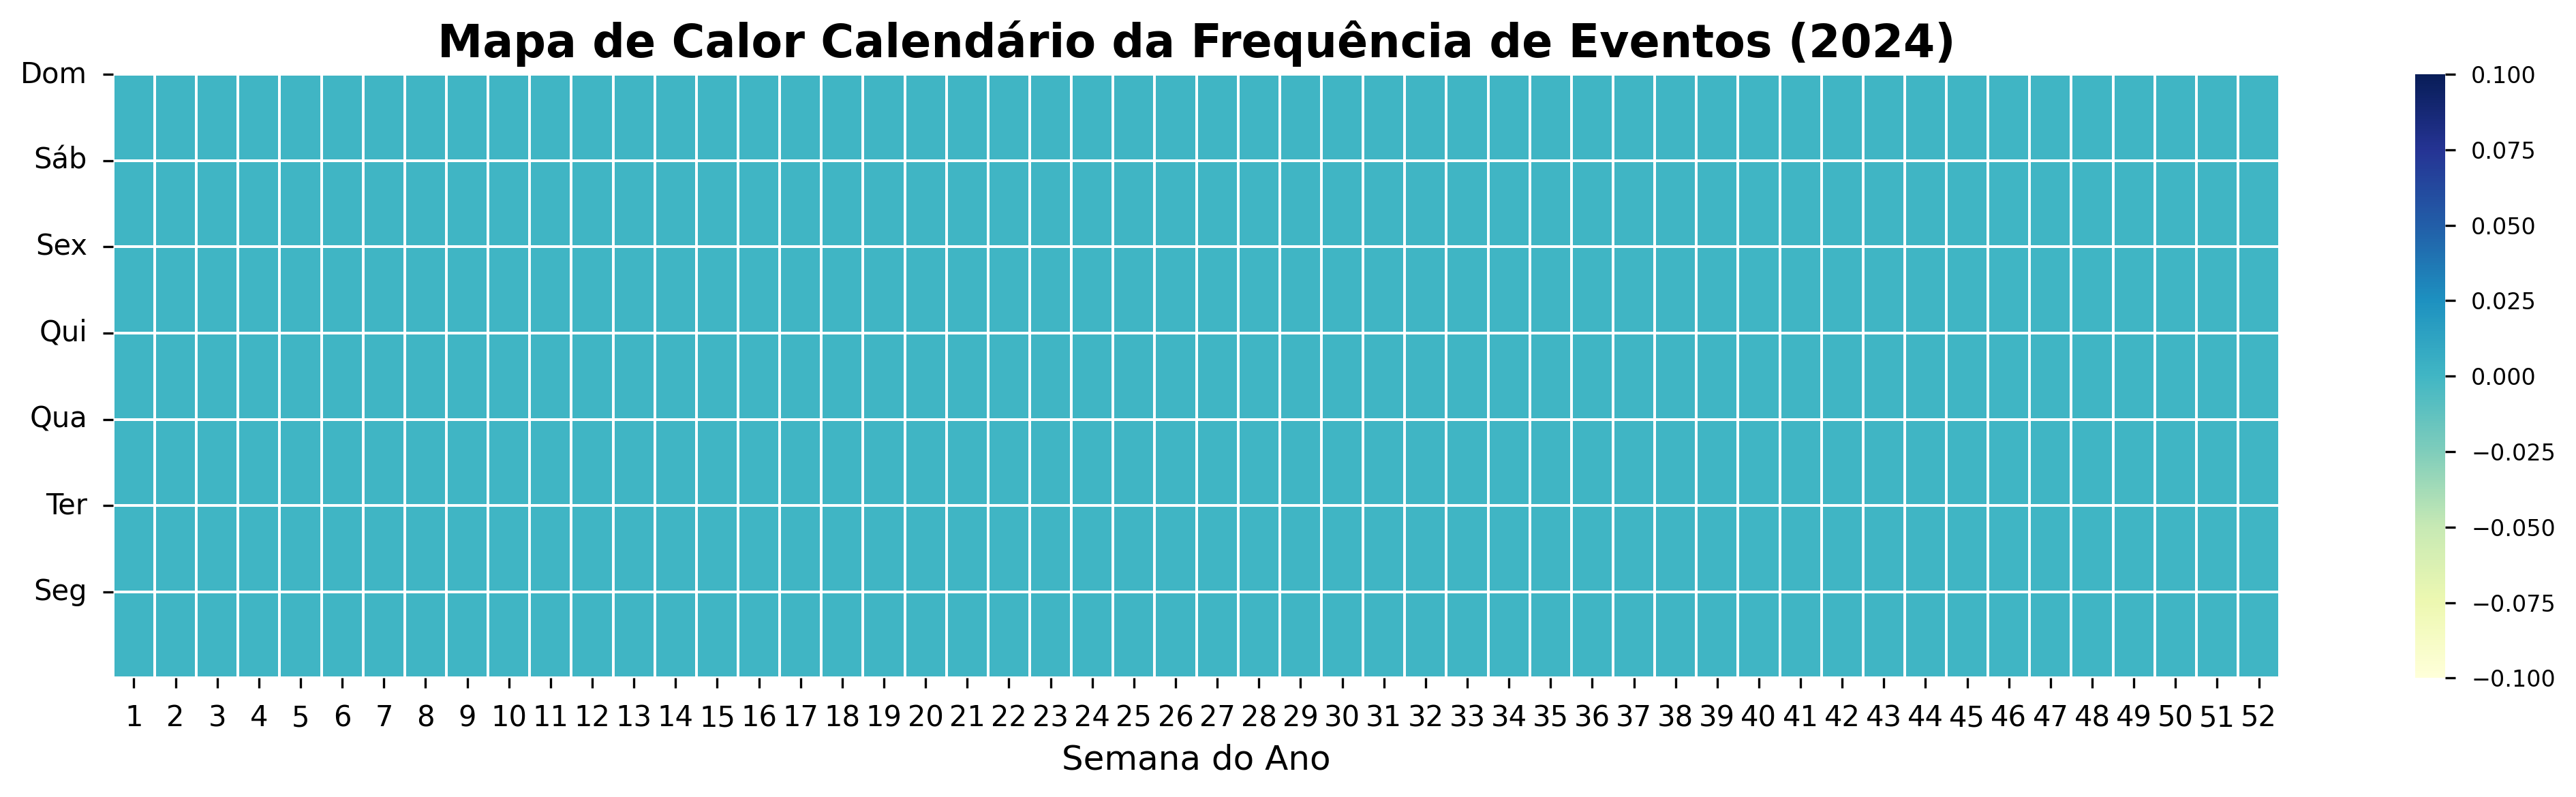

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Nota: Replicar o px.calendar exige uma transformação de dados.
# Esta é uma implementação customizada usando um heatmap do Seaborn.

# Focar no ano mais recente para a visualização, como no código original
latest_year = ocorrencias['year'].max()
df_year = ocorrencias[ocorrencias['year'] == latest_year].copy()
print(f"Gerando mapa de calor para o ano: {latest_year}")

if not df_year.empty:
    # Contar eventos por dia
    events_by_day = df_year.groupby('data_inicio').size().reset_index(name='count')
    events_by_day['data_inicio'] = pd.to_datetime(events_by_day['data_inicio'])
    events_by_day.set_index('data_inicio', inplace=True)

    # Criar um índice de todos os dias do ano
    all_days = pd.date_range(start=f'{latest_year}-01-01', end=f'{latest_year}-12-31', freq='D')
    events_by_day = events_by_day.reindex(all_days, fill_value=0)

    # Preparar dados para o heatmap
    events_by_day['week'] = events_by_day.index.isocalendar().week
    events_by_day['day_of_week'] = events_by_day.index.dayofweek # Segunda=0, Domingo=6
    
    # Lidar com semanas que se estendem pelo final/início do ano (ex: semana 53)
    if 53 in events_by_day['week'].unique() and 1 in events_by_day['week'].unique():
         events_by_day['week'] = events_by_day['week'].replace(53, 0)
    
    calendar_map = events_by_day.pivot_table(index='day_of_week', columns='week', values='count')
    calendar_map = calendar_map.sort_index(ascending=False) # Inverter para Domingo ficar em baixo

    # Plotar
    plt.figure(figsize=(14, 4))
    sns.heatmap(calendar_map, cmap='YlGnBu', linewidths=.5, cbar=True, annot=False)
    
    plt.title(f'Mapa de Calor Calendário da Frequência de Eventos ({latest_year})', fontsize=16, weight='bold')
    plt.xlabel('Semana do Ano', fontsize=12)
    plt.ylabel('')
    dias_semana_pt = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
    plt.yticks(ticks=range(6, -1, -1), labels=dias_semana_pt, rotation=0)
    plt.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
    plt.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado disponível para o ano selecionado para gerar o mapa de calor.")

### Scatter Plot: Start Time vs. Duration

- Explore any relationship between the start time of an event and its duration.

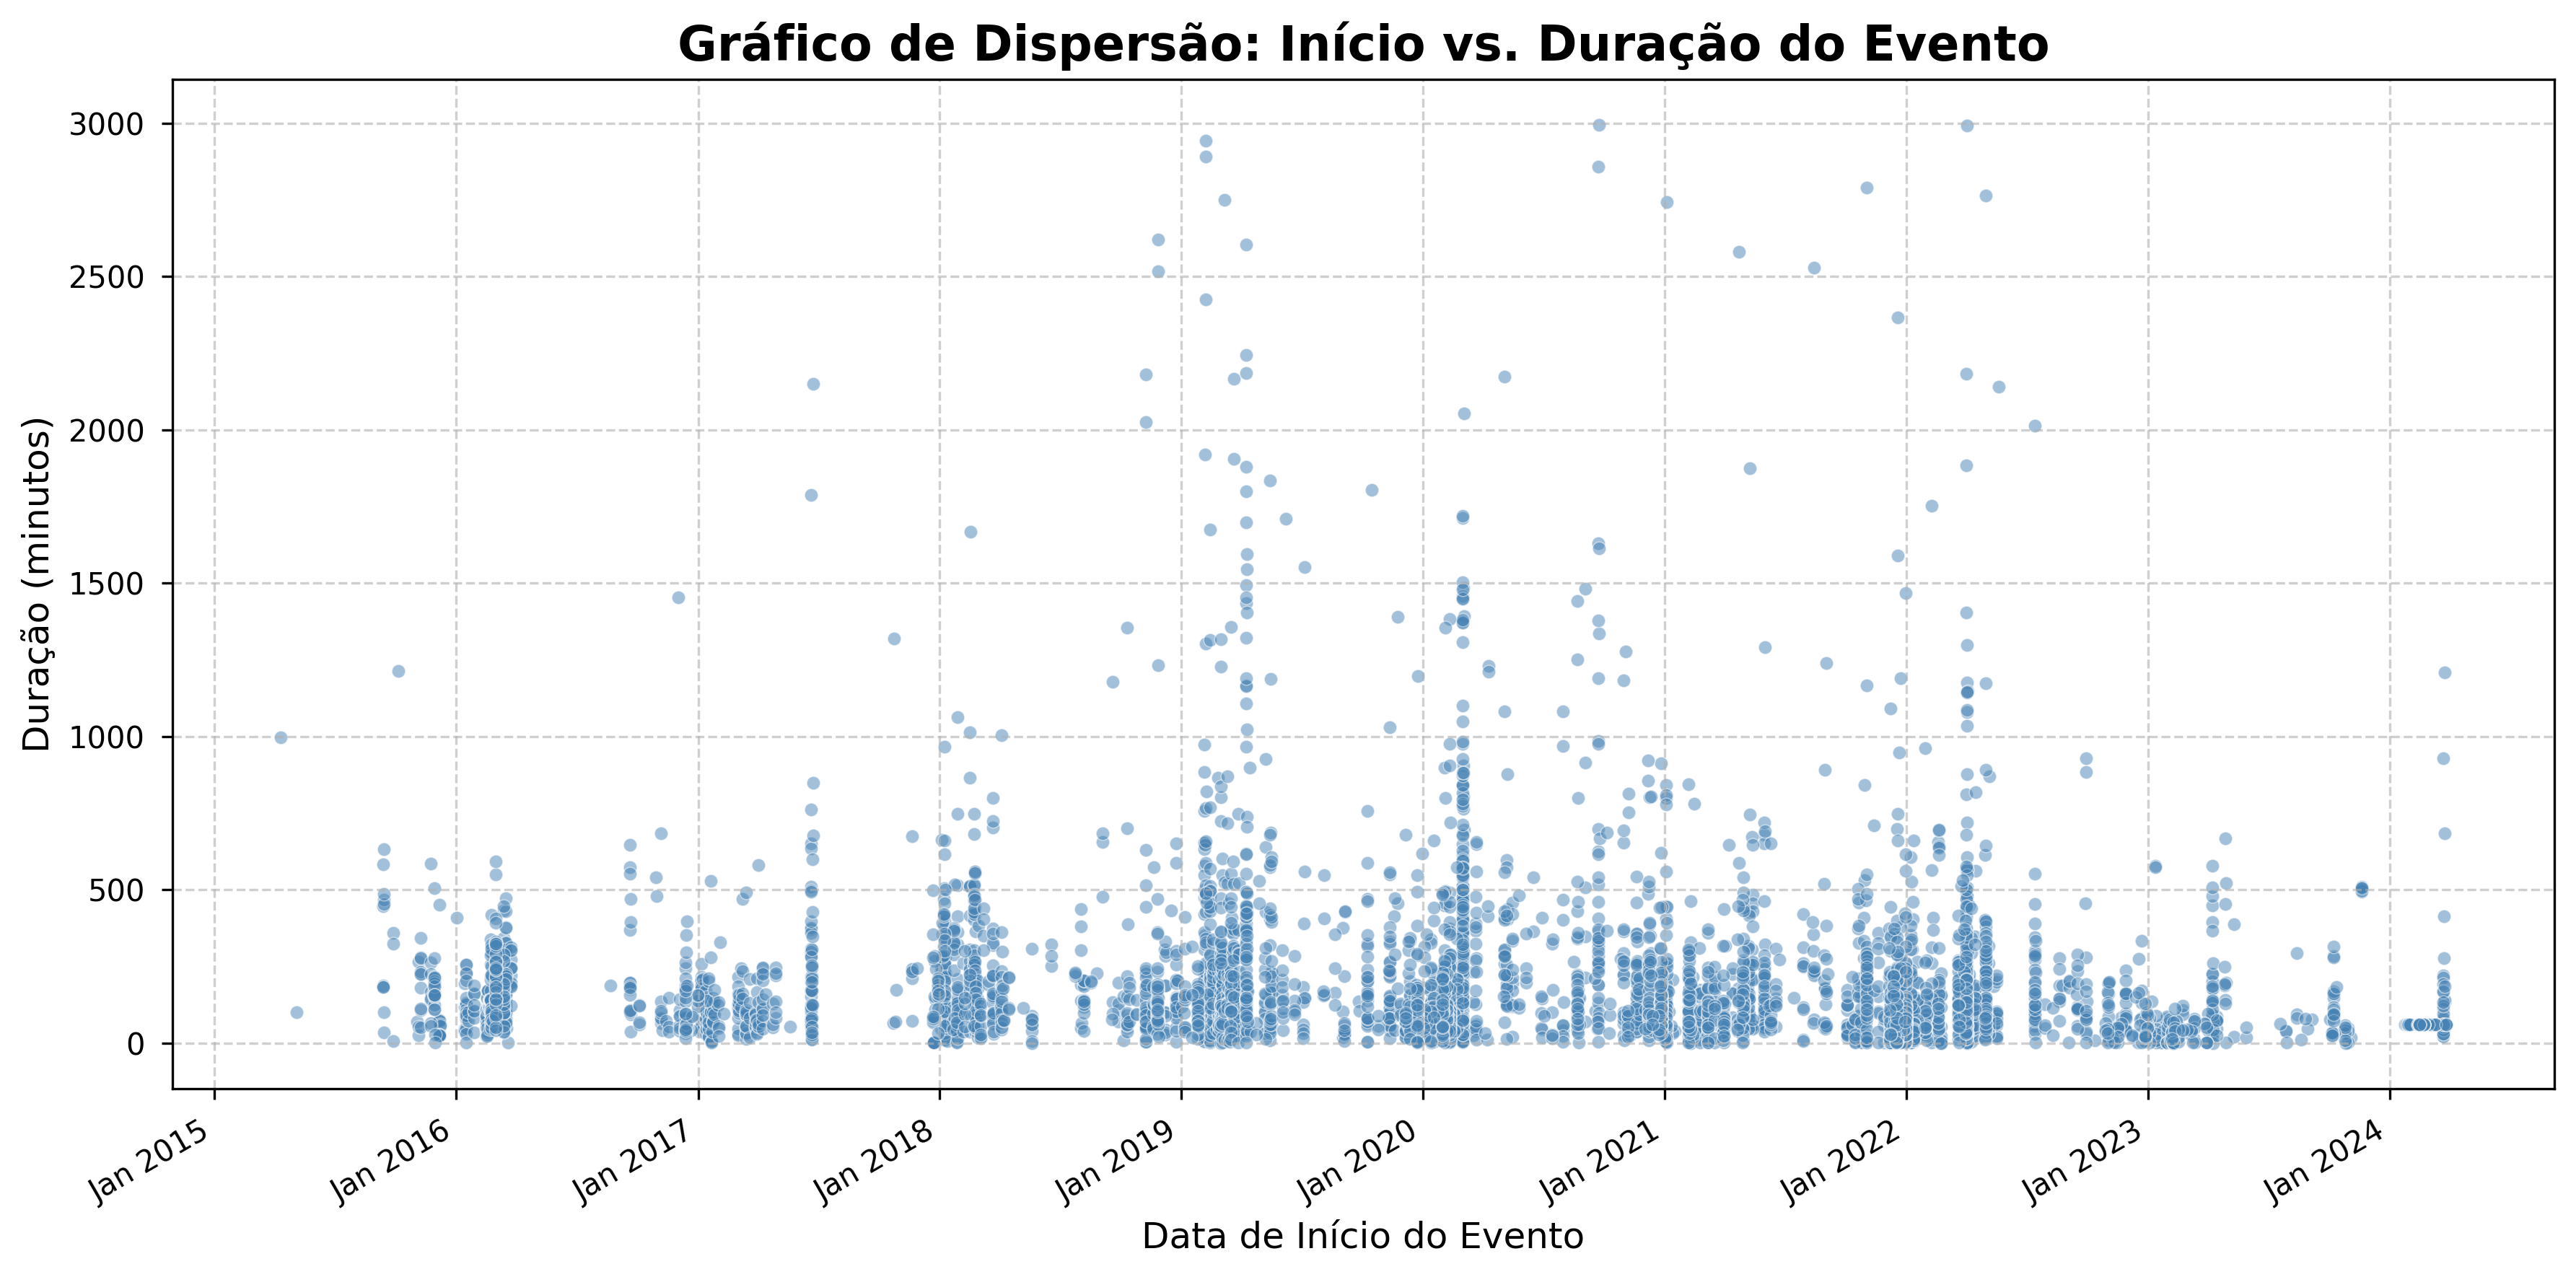

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Estilo e resolução
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# --- Gráfico de Dispersão: Início vs. Duração ---
fig, ax = plt.subplots(figsize=(12, 6))

# Filtrar outliers de duração para melhor visualização
data_filtered = ocorrencias[ocorrencias['duration_minutes'] < 3000]

sns.scatterplot(
    data=data_filtered,
    x='data_inicio',
    y='duration_minutes',
    alpha=0.5,
    s=20, # Tamanho do ponto
    color='steelblue',
    ax=ax
)

# Estilização
ax.set_title('Gráfico de Dispersão: Início vs. Duração do Evento', fontsize=16, weight='bold')
ax.set_xlabel('Data de Início do Evento', fontsize=12)
ax.set_ylabel('Duração (minutos)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

# Formatação do eixo X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 4. Advanced Visualizations

### Bubble Chart

- Visualize event duration by severity over time using a bubble chart

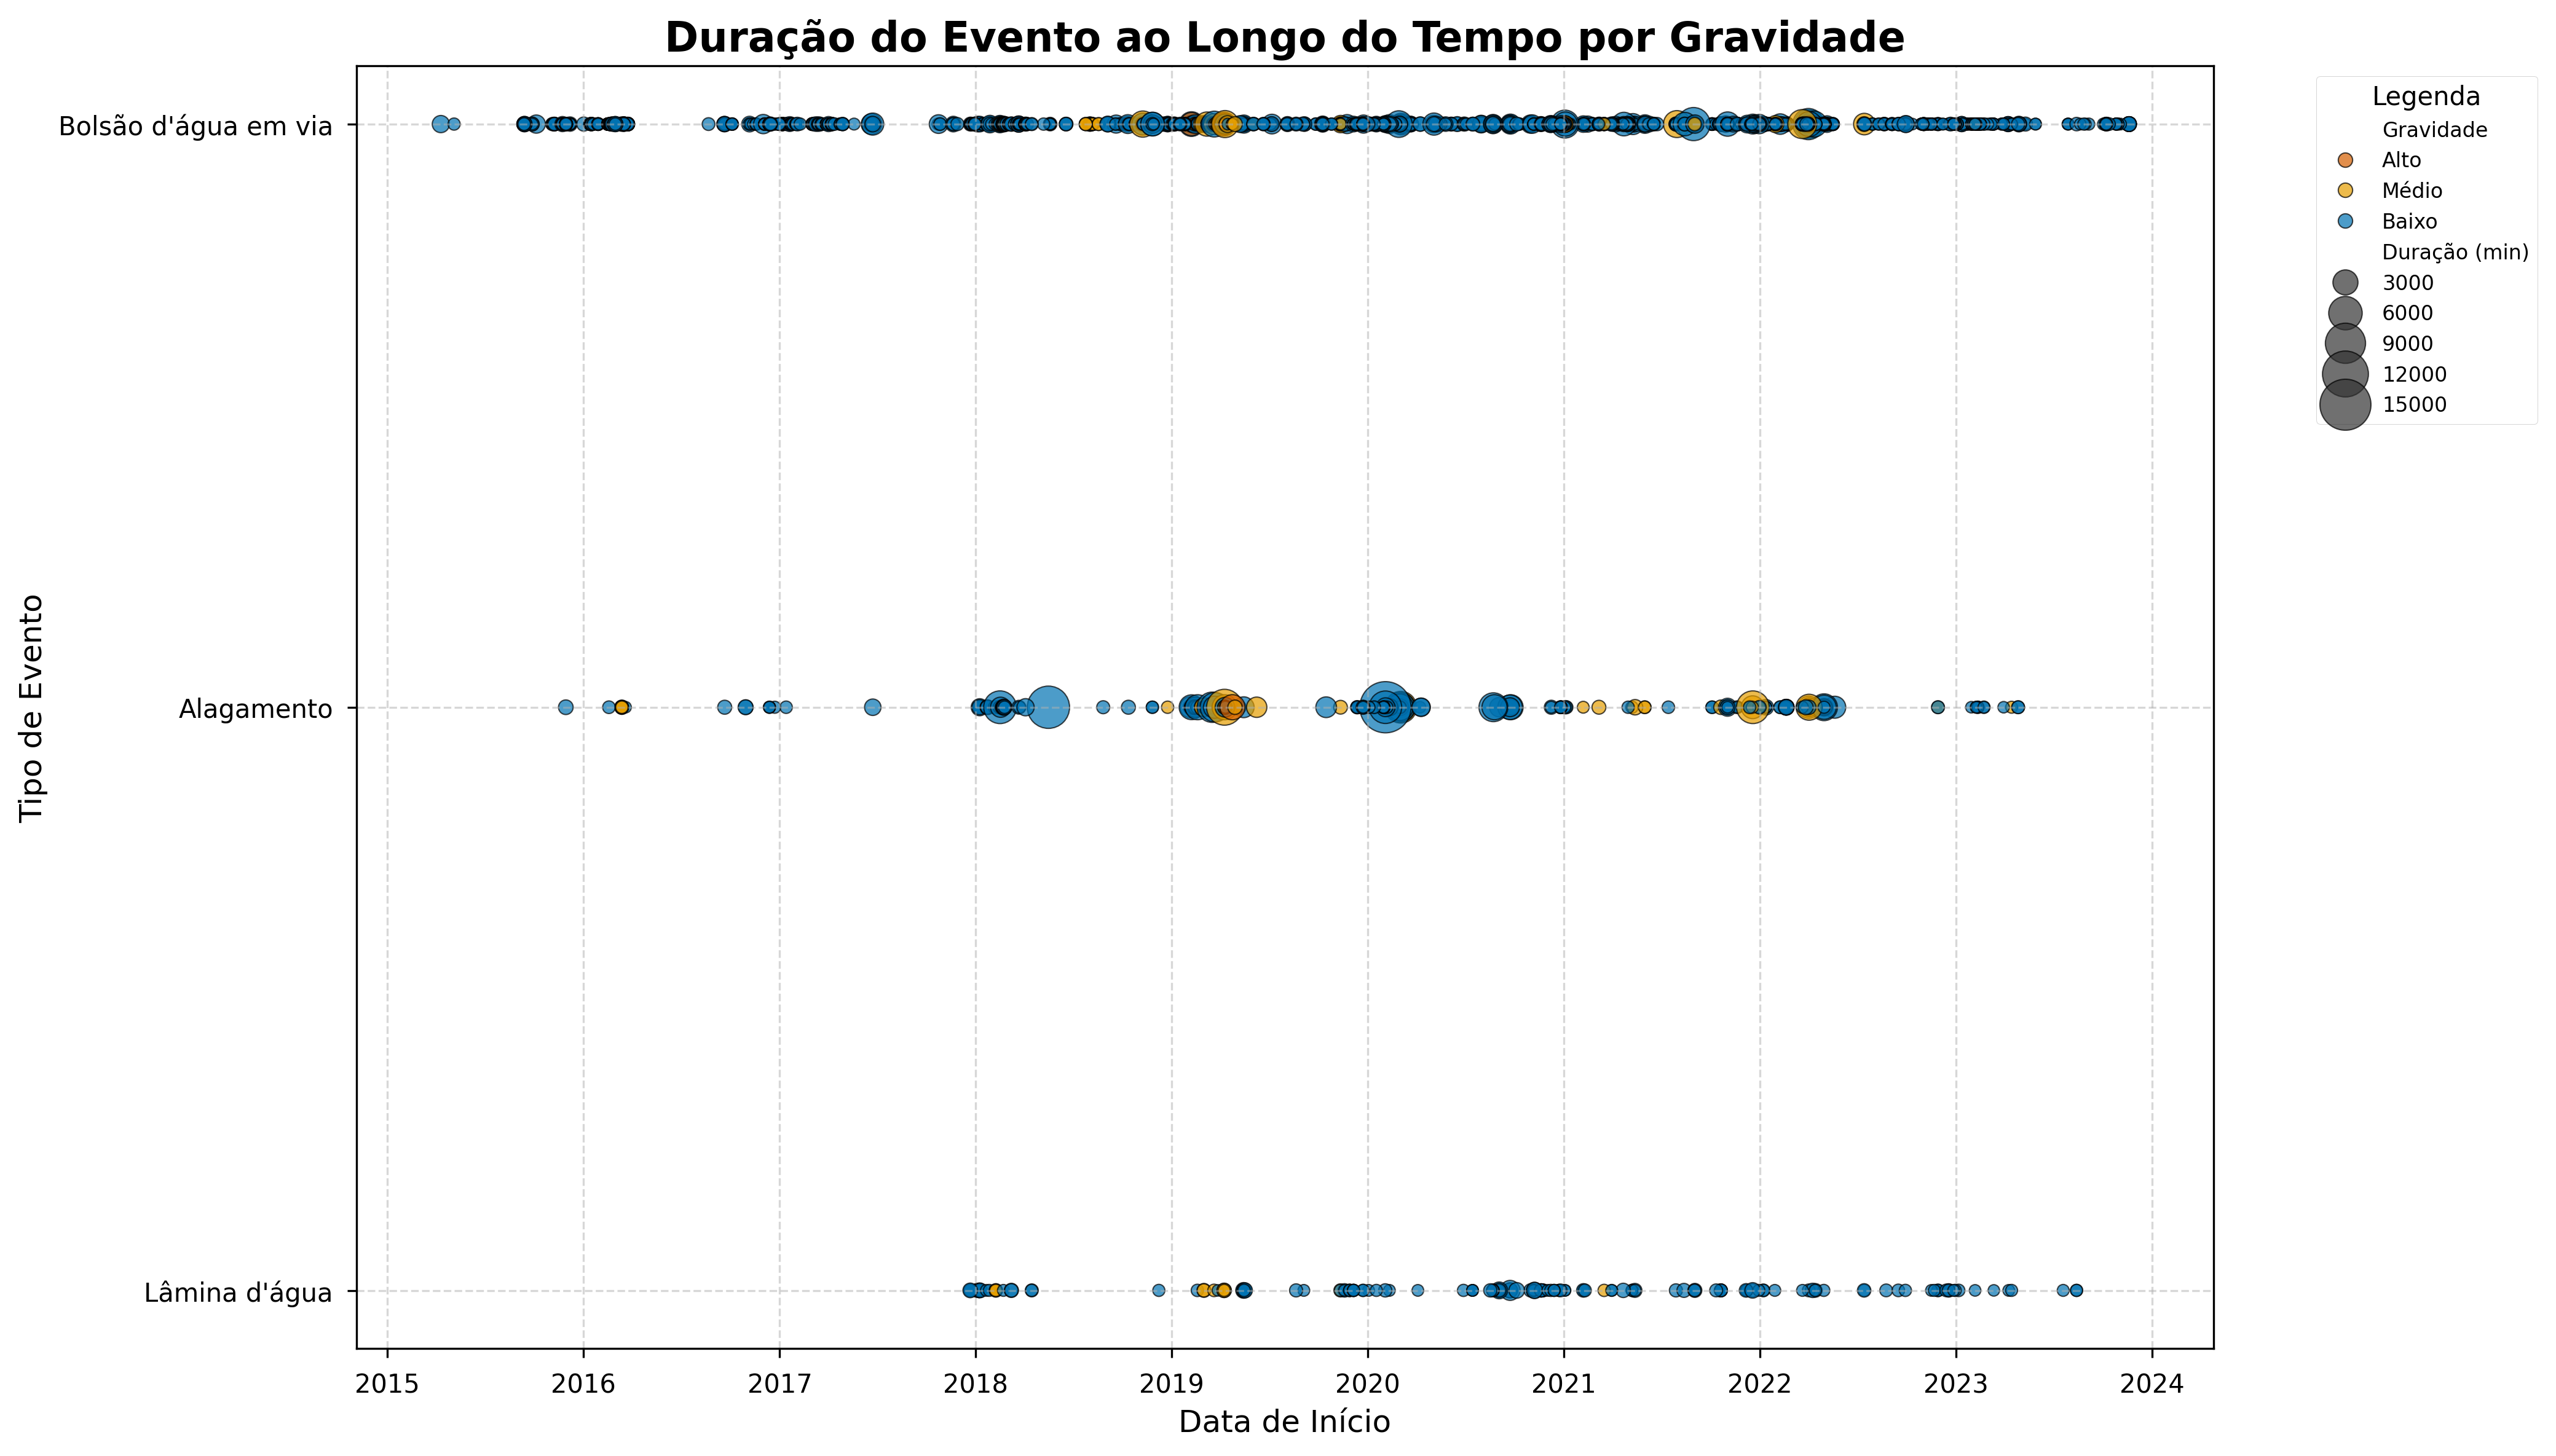

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Estilo e resolução
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# Preparar dados como no código original
ocorrencias_cut = ocorrencias[ocorrencias['gravidade'].isin(['Baixo', 'Medio', 'Alto'])].copy()
gravidades_ordem = ['Alto', 'Medio', 'Baixo']

# --- Gráfico de Bolhas: Duração por Gravidade ao Longo do Tempo ---
plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    data=ocorrencias_cut,
    x='data_inicio',
    y='tipo',
    hue='gravidade',
    size='duration_minutes',
    sizes=(20, 400), # Intervalo do tamanho das bolhas
    hue_order=gravidades_ordem,
    palette={'Alto': '#D55E00', 'Medio': '#E69F00', 'Baixo': '#0072B2'},
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Estilização
ax.set_title('Duração do Evento ao Longo do Tempo por Gravidade', fontsize=16, weight='bold')
ax.set_xlabel('Data de Início', fontsize=12)
ax.set_ylabel('Tipo de Evento', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(axis='x', labelsize=10)  # Increase x-axis tick label size
ax.tick_params(axis='y', labelsize=10)  # Increase y-axis tick label size

# Melhorar a legenda
handles, labels = ax.get_legend_handles_labels()
# Mapear e traduzir os rótulos da legenda
label_translation = {
    'gravidade': 'Gravidade', 'duration_minutes': 'Duração (min)',
    'Alto': 'Alto', 'Medio': 'Médio', 'Baixo': 'Baixo'
}
new_labels = [label_translation.get(label, label) for label in labels]
ax.legend(handles, new_labels, title='Legenda', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 7. Multi-Dimensional & Interactive Dashboards

### Faceted Plots

- Use facet grids to create small multiples by “bairro” or event type for both temporal and spatial plots.

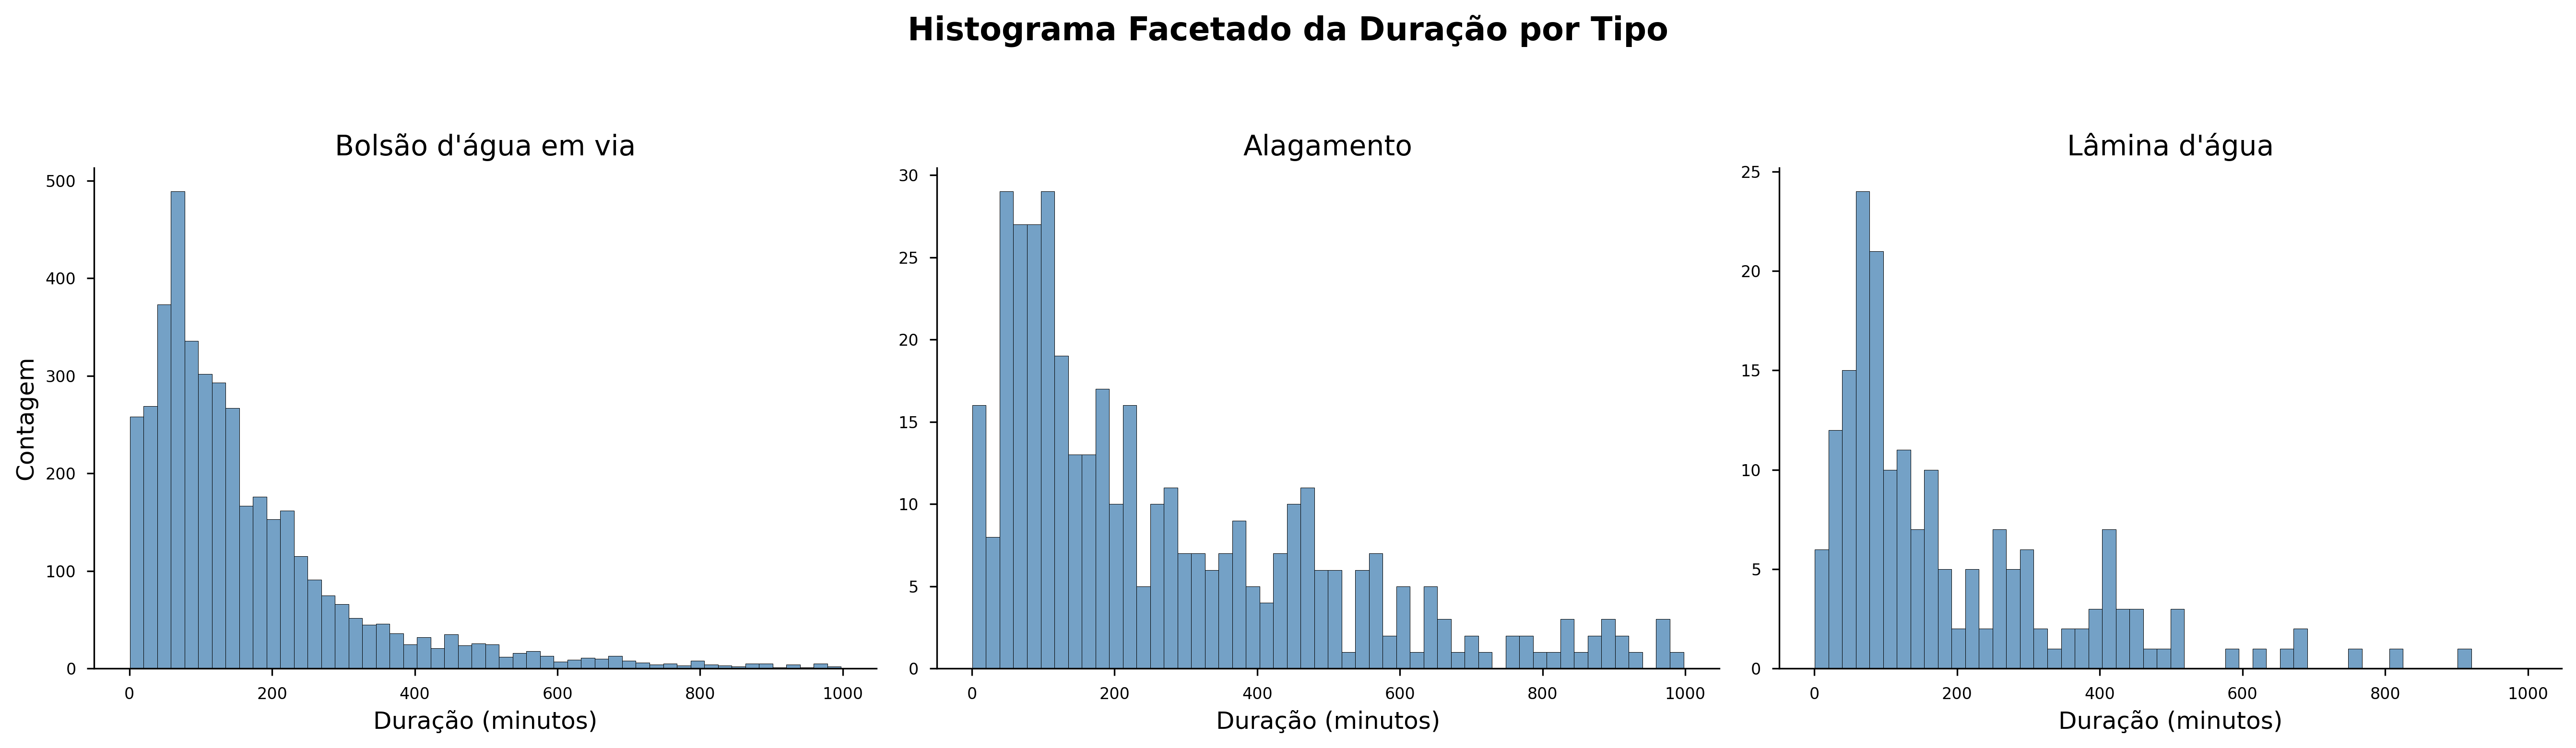

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo e resolução
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 300

# Filtrar outliers de duração para melhor visualização das facetas
ocorrencias_filtered = ocorrencias[ocorrencias['duration_minutes'] < 1000]

# --- Histograma Facetado ---
g = sns.displot(
    data=ocorrencias_filtered,
    x='duration_minutes',
    # hue='bairro',
    col='tipo',
    kind='hist',
    multiple='stack',
    height=5,
    aspect=1.2,
    col_wrap=3, # Envolve as colunas se houver mais de 3 tipos,
    facet_kws={'sharey': False},
    # palette='viridis'
    color='steelblue'
)

# Estilização
g.fig.suptitle('Histograma Facetado da Duração por Tipo', y=1.03, fontsize=16, weight='bold')
g.set_axis_labels('Duração (minutos)', 'Contagem', fontsize=12)
g.set_titles("{col_name}", size=14)  # títulos de cada facet
# g.legend.set_title('Gravidade')
# g._legend.remove()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()